In [63]:
# Imports 

import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import patches
from pathlib import Path
import seaborn as sns

import matplotlib as mpl


import networkx as nx
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import squareform

from vizman import viz
viz.set_visual_style()
default_sizes = viz.load_data_from_json("sizes.json")
default_colors = viz.load_data_from_json("colors.json")
default_cmaps = viz.give_colormaps()

from src.visualization.one_simple_plot import plot_one_aesthetic_plot

from scipy.stats import entropy
# from skimage.measure import shannon_entropy

In [64]:
# Colors 

lecker_red = default_colors["warms"]["LECKER_RED"]
bone_white = default_colors["neutrals"]["BONE_WHITE"]
olive_gray = default_colors["neutrals"]["OLIVE_GRAY"]
halfblack = default_colors["neutrals"]["HALF_BLACK"]

# get the colors for -1 and 1
cmap = default_cmaps["db_bw_lr"].resampled(2)
color_neg1 = cmap(0)
color_pos1 = cmap(1)

black_white_map = plt.cm.colors.LinearSegmentedColormap.from_list(
        f'custom_cmap_black_white', 
        [
            bone_white,
            "black",
         ]
    )



# Get colormaps
dark2 = plt.get_cmap("Dark2")
set1 = plt.get_cmap("Set1")

# Extract colors
dark2_colors = list(dark2.colors)
set1_colors = [c for i, c in enumerate(set1.colors)] # if i != 4]

# Combine into one list
all_colors = dark2_colors + set1_colors
# remove index 13
all_colors.pop(13)

# reverse, just out of aesthetic preference
all_colors = all_colors # [::-1]

In [65]:
dataset_name = "hcp_schaefer_100_dataset" # lexis_data" # "suarez_MaMI_dataset"
experiment_name = "105_distance_metrics_mst_animal_0" # 05_mst_animal_0" # 02_ring_sweeps_animal_0" # 05_mst_animal_0" # 
# experiment_name = "02_ring_sweeps_animal_0" # "01_ring_sweep_animal_0" # "95_ring_seed_100_sweep_animal_206"
# experiment_name = "03_no_ring_sweeps_animal_0"
base_path = Path(f"/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/gnm/{dataset_name}/{experiment_name}")
save_path = base_path / f"all_metrics_for_{experiment_name}.csv"


filtering_df_path = base_path / f"all_metrics_for_{experiment_name}.csv" # _updated.csv"
filtering_df = pd.read_csv(filtering_df_path)

output_path = Path(base_path) / "ground_truth_analysis"
output_path.mkdir(exist_ok=True)

In [66]:
# Admittedly uggly hack: Getting colors for each metric name, and then reset the same variable for a different purpose... 


# Get the name of all measures
# all_dist_measures = ['communicability_corr',
#                     'dc_network_mutual_information',
#                     'network_mutual_information',
#                     'f1',
#                     'jaccard',
#                     'communicability_jsd',
#                     'netrd_non_backtracking_spectral',
#                     'resistance',
#                     'delta_con',
#                     'hamming',
#                     'frobenius',
#                     'net_simile',
#                     'spectral_distance_adjacency',
#                     'spectral_distance_norm_laplacian',
#                     'energy',
#                     'portrait'
#                 ]


# metric_colors = {}

# for i, metric_name in enumerate(all_dist_measures):
#         metric_colors[metric_name] = all_colors[i]


metric_colors = {'communicability_corr': (0.6, 0.6, 0.6),
                'dc_network_mutual_information': (0.9686274509803922,
                0.5058823529411764,
                0.7490196078431373),
                'network_mutual_information': (0.6509803921568628,
                0.33725490196078434,
                0.1568627450980392),
                'f1': (1.0, 0.4980392156862745, 0.0),
                'jaccard': (0.596078431372549, 0.3058823529411765, 0.6392156862745098),
                'communicability_jsd': (0.30196078431372547,
                0.6862745098039216,
                0.2901960784313726),
                'netrd_non_backtracking_spectral': (0.21568627450980393,
                0.49411764705882355,
                0.7215686274509804),
                'resistance': (0.8941176470588236, 0.10196078431372549, 0.10980392156862745),
                'delta_con': (0.4, 0.4, 0.4),
                'hamming': (0.6509803921568628, 0.4627450980392157, 0.11372549019607843),
                'frobenius': (0.9019607843137255, 0.6705882352941176, 0.00784313725490196),
                'net_simile': (0.4, 0.6509803921568628, 0.11764705882352941),
                'spectral_distance_adjacency': (0.9058823529411765,
                0.1607843137254902,
                0.5411764705882353),
                'spectral_distance_norm_laplacian': (0.4588235294117647,
                0.4392156862745098,
                0.7019607843137254),
                'energy': (0.8509803921568627, 0.37254901960784315, 0.00784313725490196),
                'portrait': (0.10588235294117647, 0.6196078431372549, 0.4666666666666667)}



# Get the name of all measures
all_dist_measures = [
    "energy", 
    "portrait", 
    "spectral_distance_adjacency",
    # "spectral_distance_norm_laplacian", 
    
    "communicability_corr",
    # "communicability_jsd",
    # "network_mutual_information",
    # "dc_network_mutual_information", 
    
    "net_simile", 
    "netrd_non_backtracking_spectral", 
        "resistance", 
    "delta_con", 
    
    # "f1", 
    # "hamming",
    "frobenius", 
    # "jaccard", 
]

In [67]:
# Method names for plotting

method_names = {
    'portrait': 'Portrait', #  Divergence',
    'energy': 'Energy', #  Distance',
        'spectral_distance': 'Spectral Distance', # Different versions?? 
    'spectral_distance_laplacian': 'Spectral (Laplacian)',
    'spectral_distance_norm_laplacian': 'Spectral (Normalized Laplacian)',
    'spectral_distance_adjacency': 'Spectral (Adjacency)',
    'f1': 'F1', #  Score',
    'hamming': 'Hamming', # Distance',
        'communicability': 'Communicability Correlation', #  Distance',
        'graph_kernel': 'Graph Kernel Distance old',
        'multiplex_layer_similarity': 'Multiplex Layer Similarity',
    'cosine_embedding': 'Cosine Embedding', #  Distance',
    'graph_edit_distance': 'Graph Edit', #  Distance',
    'network_mutual_information': 'Network Mutual Information',
    'dc_network_mutual_information': 'DC Network Mutual Information',
        'hungarian_alignment': 'Hungarian Alignment',
    'graph_kernel_networkx': 'Graph Kernel', #  Distance',
    'delta_con': 'DeltaCon',
    'delta_con_distance': 'DeltaCon (distance)', # Distance',
        'resistance_distance': 'Resistance old', #  Distance',
        'wasserstein_gromov': 'Wasserstein-Gromov Distance',
    'wasserstein_sinkhorn': 'Wasserstein-Sinkhorn', #  Distance',

        'edit_distance': 'Edit Distance old',
    'communicability_corr': 'Communicability Correlation',
    'communicability_mse': 'Communicability MSE',
    'communicability_jsd': 'Communicability JSD',
    'frobenius': 'Frobenius', #  Distance',
    'jaccard': 'Jaccard', #  Distance',

    'resistance': 'Resistance', #  Distance',
    'net_simile': 'NetSimile', #  Distance',
    # 'net_smile': 'NetSimile', #  Distance', # !!!! Typo, remove this later (after 05 it should be fixed)
    'net_lsd': 'NetLSD', #  Distance',
    'quantum_jsd': 'Quantum JSD', #  Distance',
    'graph_diffusion': 'Graph Diffusion', #  Distance',
    'polynomial_dissimilarity': 'Polynomial Dissimilarity', #  Distance',
    'degree_divergence': 'Degree Divergence', #  Distance',
    'onion_divergence': 'Onion Divergence', #  Distance',

    "network_mutual_information_old": "Network Mutual Information old",
    "netrd_deltacon": "NetRD DeltaCon",
    "netrd_communicability_jsd": "NetRD Communicability JSD",
    "distributional_nbd": "Distributional NBD",
    "dk_series": "DK Series",
    "d_measure": "D Measure",
    "netrd_frobenius": "NetRD Frobenius",
    "netrd_hamming": "NetRD Hamming",
    "hamming_ipsen_mikhailov": "Hamming Ipsen-Mikhailov",
    "ipsen_mikhailov": "Ipsen-Mikhailov",
    "netrd_jaccard": "NetRD Jaccard",
    "netrd_laplacian_spectral": "NetRD Laplacian Spectral",
    "netrd_non_backtracking_spectral": "Spectral (Non-Backtracking)", # NetRD Non-Backtracking Spectral",
    "netrd_portrait_divergence": "NetRD Portrait Divergence",
}

# Individual heatmaps (works like a charm)
# for m in all_methods:
#     plot_comparison_landscape(m)

# metric_colors = {}
# colors = sns.color_palette("tab20", len(method_names.values()))
# for i, (metric_name, metric_label) in enumerate(zip(method_names.keys(), method_names.values())):
#     metric_colors[metric_name] = colors[i]


In [68]:
# Get values for every measure

matrices_of_metrics = {}

for idx, mode in enumerate(all_dist_measures):

    path = f"/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/gnm/{dataset_name}/{experiment_name}/summary_indiv_{mode}_for_exp_{experiment_name}.csv"
    df_further_measures = pd.read_csv(path)
    
    # Get the metric column
    metric_col = [col for col in df_further_measures.columns if col not in ["eta", "gamma", "network_index", "filename", "id"]]
    if not metric_col:
        raise ValueError(f"No metric column found in {df.columns}")
    
    # Round eta and gamma to a reasonable number of decimal places (e.g., 2 or 3)
    df_further_measures['eta'] = df_further_measures['eta'].round(2)
    df_further_measures['gamma'] = df_further_measures['gamma'].round(2)
    filtering_df['eta'] = filtering_df['eta'].round(2)
    filtering_df['gamma'] = filtering_df['gamma'].round(2)

    # Now merge
    if "no" in experiment_name: # FILTER BY NUMBER COMPONENTS. Alternative: not "ring" in experiment_name:
        df_further_measures = df_further_measures.merge(filtering_df[['eta', 'gamma', 'n_connected_components']], 
                    on=['eta', 'gamma'], 
                    how='left')
        # Filter
        df_further_measures = df_further_measures[df_further_measures['n_connected_components'] <= 1]
    
    else: 
        df_further_measures = df_further_measures.merge(filtering_df[['eta', 'gamma']], 
                    on=['eta', 'gamma'], 
                    how='left')



    # Turn df into a pivot table. If there are multiple values for one eta-gamma pair, take the mean
    df_pivot = df_further_measures.pivot_table(index='gamma', columns='eta', values=metric_col[0], aggfunc='mean')

    # Min-max normalize the values to [0, 1]
    df_pivot = (df_pivot - df_pivot.min().min()) / (df_pivot.max().max() - df_pivot.min().min())
    
    # Store the matrix as a numpy array
    matrix = df_pivot.values[::-1]
    if mode in ["f1", 
                "multiplex_layer_similarity", 
                "jaccard", 
                # "communicability_jsd", 
                "communicability_corr",
                "network_mutual_information", 
                "dc_network_mutual_information", 
            ]: # TODO: WHICH OTHER SIMILARITY METRICS? 
        matrix = 1 - matrix  # Invert for similarity measures

    # if mode == "resistance":
    #     matrix = np.log1p(matrix)  # Apply log1p transformation
        
    matrices_of_metrics[mode] = matrix


# Other stuff

In [69]:
# Functions: Correlation matrix, clustering, reordering
def load_method_data(method):
    """Load data for a specific method."""
    path = f"{base_path}/summary_indiv_{method}_for_exp_{experiment_name}.csv"
    try:
        df = pd.read_csv(path)
        metric_cols = [col for col in df.columns 
                      if col not in ["eta", "gamma", "network_index", "filename", "id"]]
        if metric_cols:
            df['metric_value'] = df[metric_cols[0]]
            
            if method in ["f1", 
                          "multiplex_layer_similarity", 
                          "jaccard", 
                          # "communicability_jsd", 
                          "communicability_corr",
                          "network_mutual_information", 
                          "dc_network_mutual_information"]: 
                
                df["metric_value"] = (df["metric_value"] - df["metric_value"].min()) / (df["metric_value"].max() - df["metric_value"].min())
                # Turn similarities into distances
                df["metric_value"] = 1 - df["metric_value"]
                print("   -> inverted " + metric_cols[0])
                
            max_idx = df['metric_value'].idxmax()
            min_idx = df['metric_value'].idxmin()
            
            # Get those eta and gamma values
            max_eta = df.loc[max_idx, 'eta']
            max_gamma = df.loc[max_idx, 'gamma']
            min_eta = df.loc[min_idx, 'eta']
            min_gamma = df.loc[min_idx, 'gamma']
            
            
            # turn this table into a pivot table and then plot it
            df_pivot = df.pivot_table(index='eta', columns='gamma', values='metric_value')
            plt.figure(figsize=(10, 8))
            sns.heatmap(df_pivot, cmap='viridis', cbar_kws={'label': 'Metric Value'})
            plt.title(f"Heatmap for {method}")
            plt.xlabel("Gamma")
            plt.ylabel("Eta")
            
            # get the 10 highest and lowest values and annotate them
            for i in range(10):
                # highest
                max_idx = df_pivot.stack().idxmax()
                plt.text(max_idx[1], max_idx[0], f"{df_pivot.loc[max_idx]:.2f}", color='white', ha='center', va='center')
                df_pivot.at[max_idx] = np.nan  # set to nan to avoid picking it again
                
                # lowest
                min_idx = df_pivot.stack().idxmin()
                plt.text(min_idx[1], min_idx[0], f"{df_pivot.loc[min_idx]:.2f}", color='black', ha='center', va='center')
                df_pivot.at[min_idx] = np.nan  # set to nan to avoid picking it again
            plt.show()

            df['method'] = method
            return df[['eta', 'gamma', 'id', 'metric_value', 'method']]
        return None
    except FileNotFoundError:
        print(f"Warning: File not found for method {method}")
        return None

def calculate_ground_truth(all_data):
    """Calculate approximated ground truth as max across methods for each eta-gamma-id."""
    ground_truth = all_data.groupby(['eta', 'gamma', 'id'])['metric_value'].max().reset_index()
    ground_truth.rename(columns={'metric_value': 'approximated_ground_truth'}, inplace=True)
    return ground_truth

def create_full_dataset(all_data, ground_truth):
    """Create dataset with all methods and ground truth."""
    pivot_data = all_data.pivot_table(
        index=['eta', 'gamma', 'id'],
        columns='method',
        values='metric_value'
    ).reset_index()
    
    if ground_truth is not None:
        full_data = pivot_data.merge(ground_truth, on=['eta', 'gamma', 'id'])
    else: 
        full_data = pivot_data
    return full_data

def calculate_correlation_matrix(full_data, methods):
    """Calculate Pearson correlation matrix between methods and ground truth."""
    cols_to_correlate = methods # + ['approximated_ground_truth']
    corr_matrix = full_data[cols_to_correlate].corr(method='pearson')
    return corr_matrix

def cluster_correlation_matrix(corr_matrix):
    """
    Cluster the correlation matrix using hierarchical clustering.
    Returns the reordered correlation matrix and the order of items.
    """
    # Convert correlation to distance
    # Use 1 - correlation for positive correlations (closer to 1 = more similar)
    distance_matrix = 1 - corr_matrix.values
    
    # Ensure all values are non-negative and clip to avoid numerical issues
    distance_matrix = np.clip(distance_matrix, 0, 2)
    
    # Make sure the matrix is symmetric
    distance_matrix = (distance_matrix + distance_matrix.T) / 2
    
    # Set diagonal to 0
    np.fill_diagonal(distance_matrix, 0)
    
    # Convert to condensed distance matrix
    condensed_dist = squareform(distance_matrix, checks=False)
    
    # Replace any NaN or inf values
    condensed_dist = np.nan_to_num(condensed_dist, nan=1.0, posinf=2.0, neginf=0.0)
    
    # Perform hierarchical clustering
    linkage_matrix = linkage(condensed_dist, method='average')  # Changed to 'average' which is more robust
    
    # Get the order from the dendrogram
    dendro = dendrogram(linkage_matrix, no_plot=True)
    order = dendro['leaves']

    # Reorder the correlation matrix
    ordered_corr = corr_matrix.iloc[order, order]
    
    return ordered_corr, order, linkage_matrix


Loading method data...


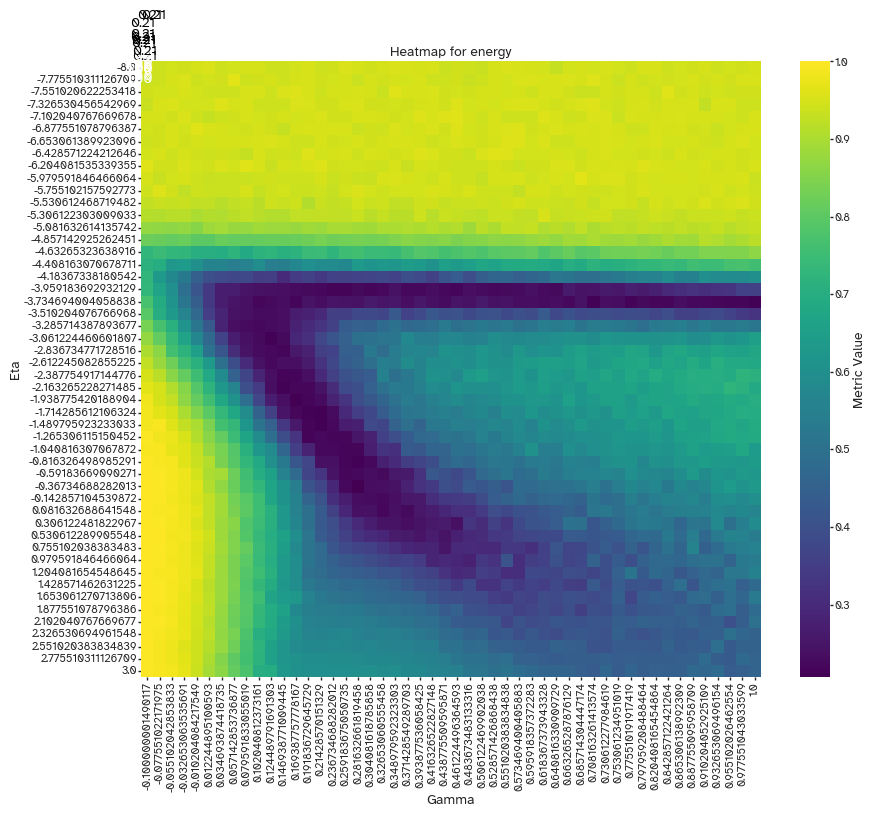

Loaded energy: 25000 rows


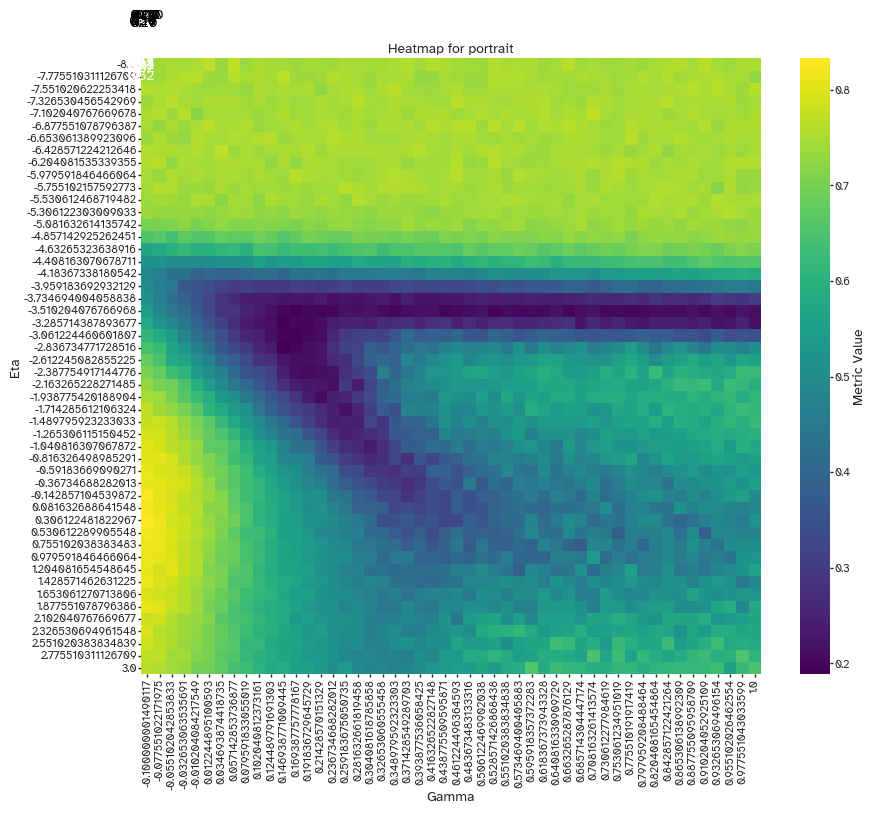

Loaded portrait: 25000 rows


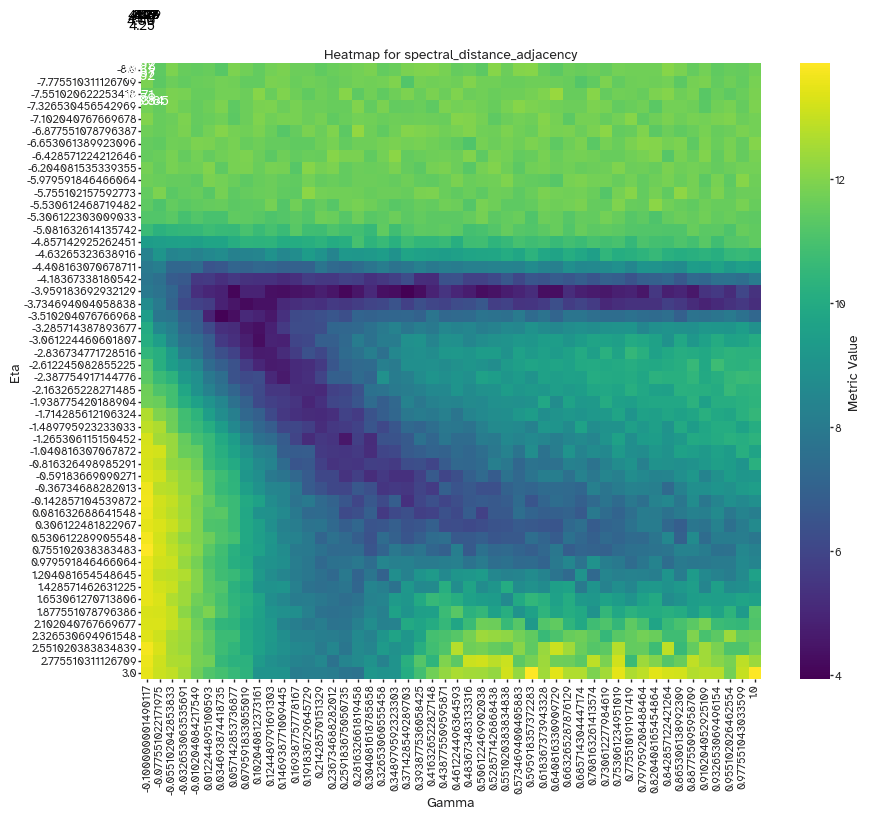

Loaded spectral_distance_adjacency: 25000 rows
   -> inverted CommCorr_subject_0


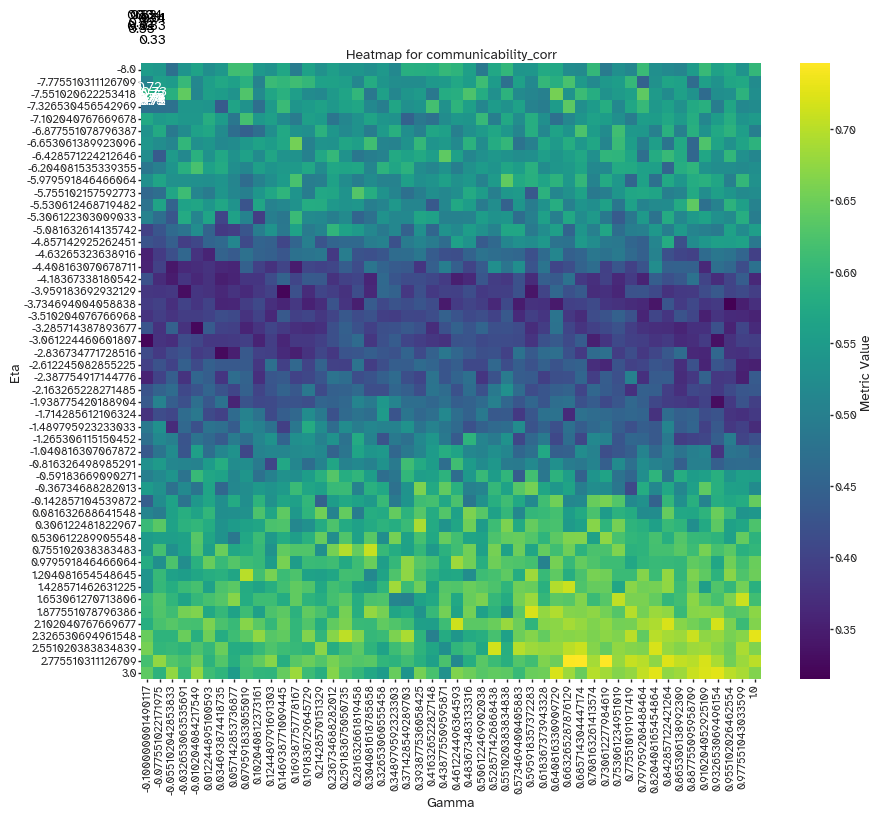

Loaded communicability_corr: 25000 rows


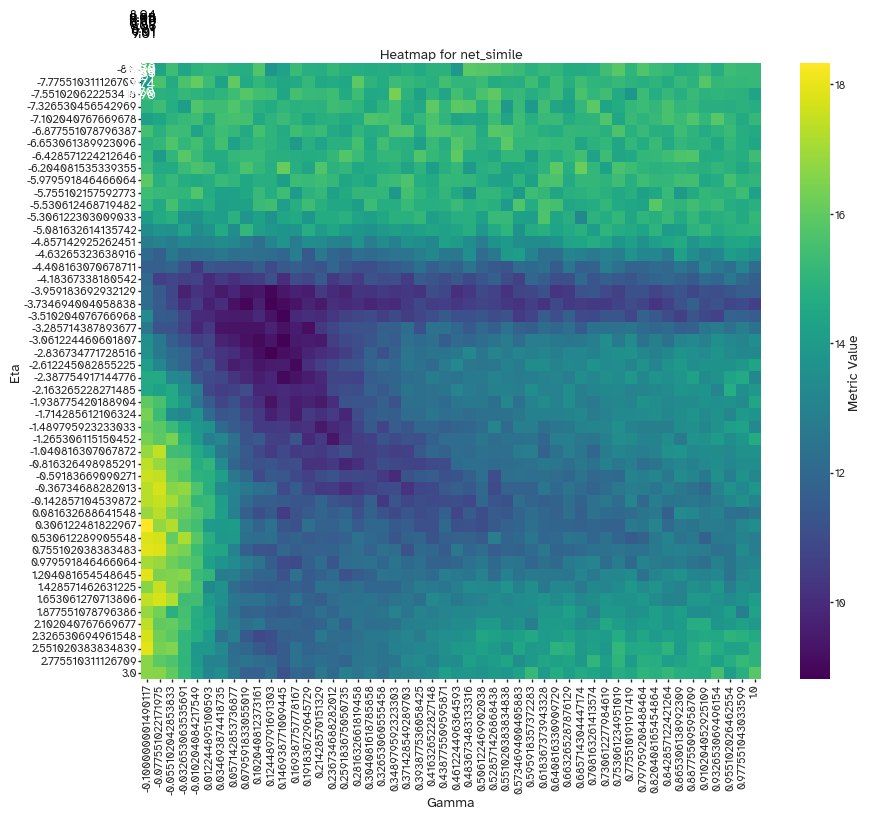

Loaded net_simile: 25000 rows


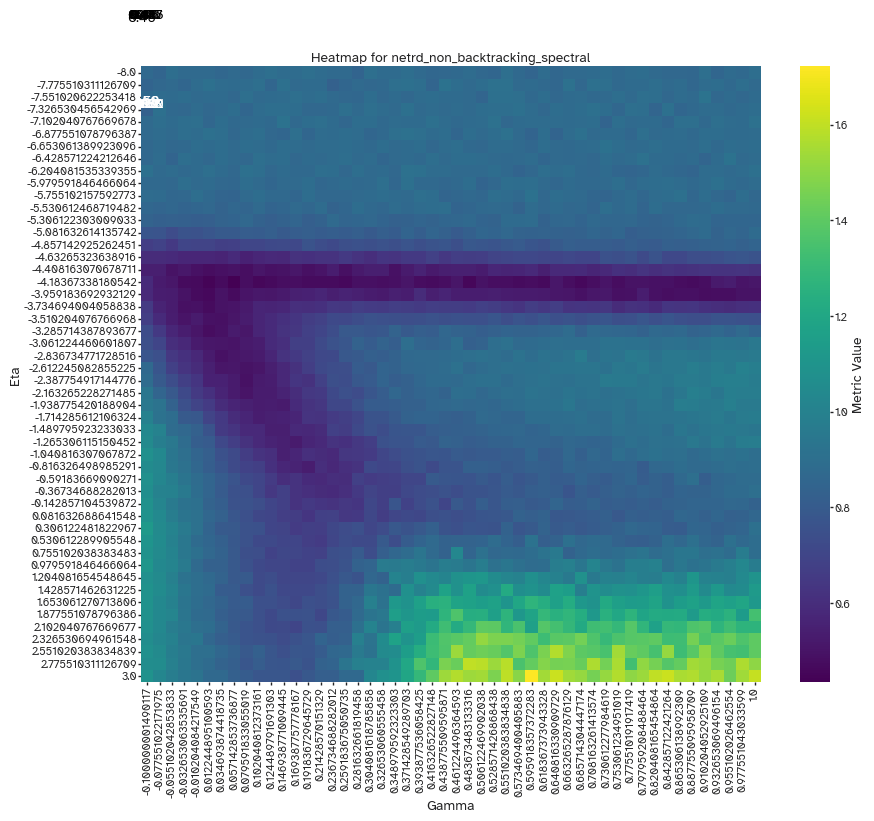

Loaded netrd_non_backtracking_spectral: 25000 rows


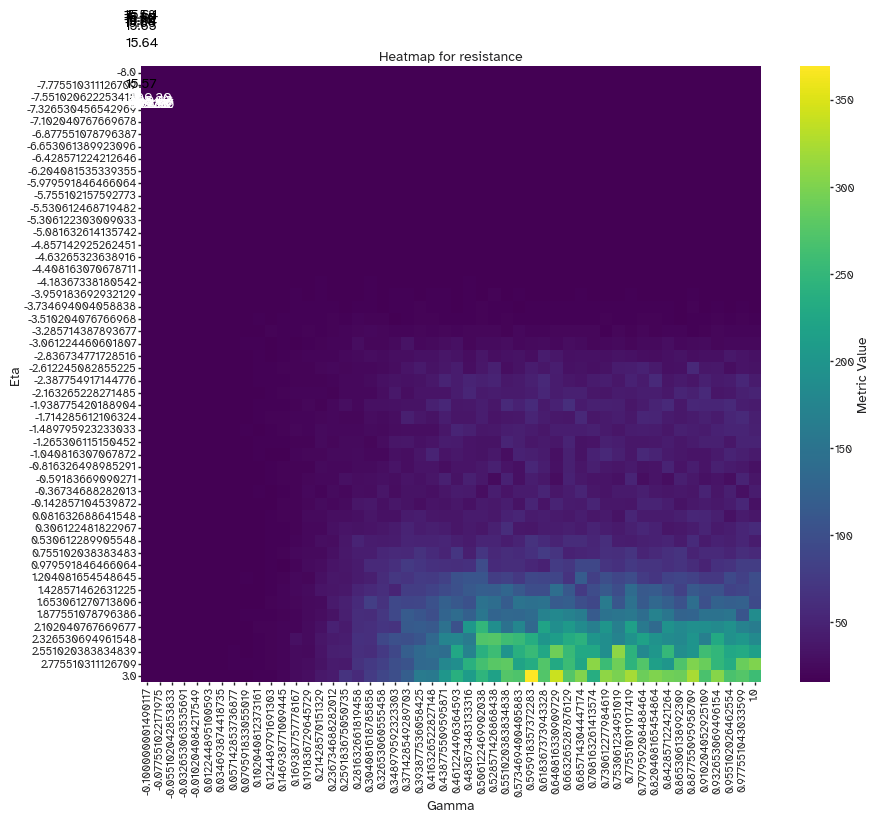

Loaded resistance: 25000 rows


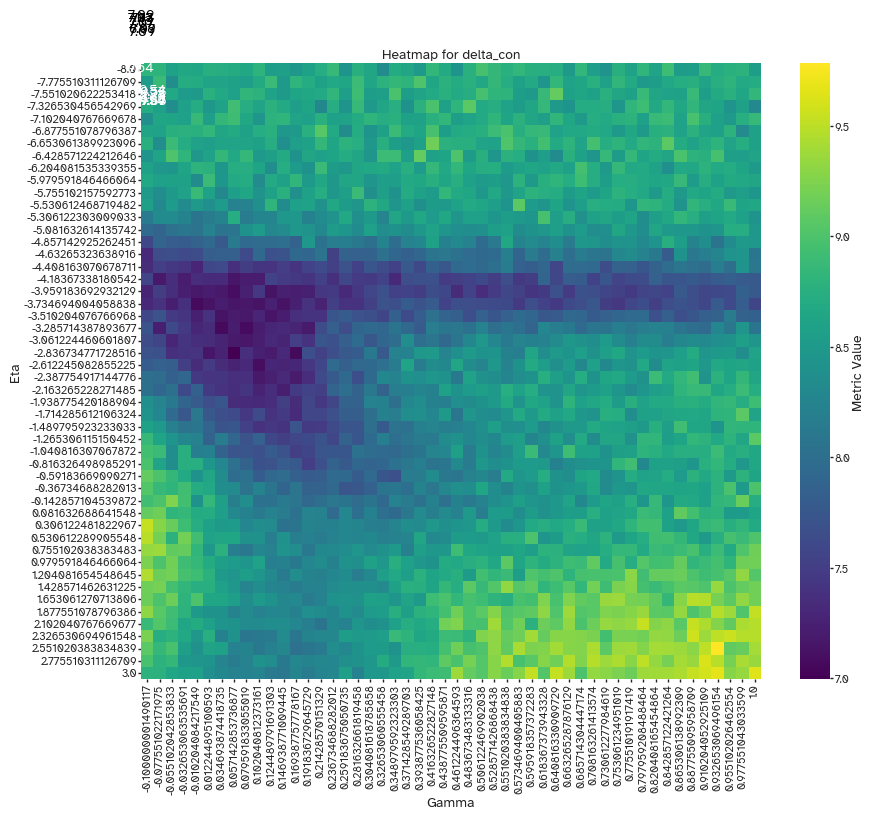

Loaded delta_con: 25000 rows


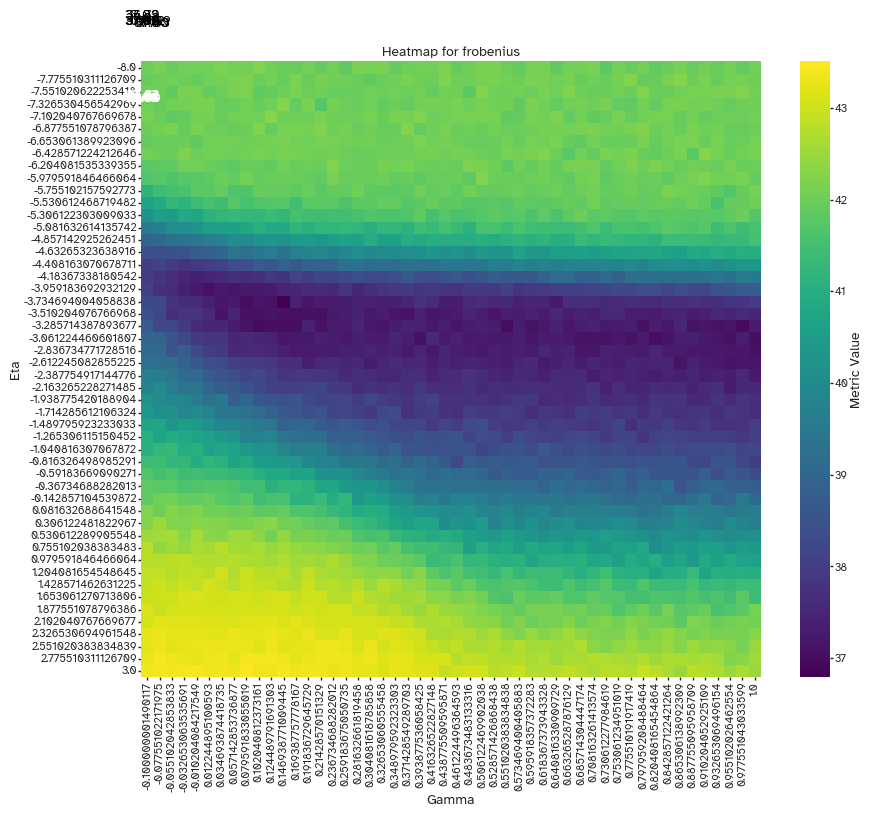

Loaded frobenius: 25000 rows


In [70]:
print("Loading method data...")
all_data_list = []
loaded_methods = []

for method in all_dist_measures:
    df = load_method_data(method)
    if df is not None:
        all_data_list.append(df)
        loaded_methods.append(method)
        print(f"Loaded {method}: {len(df)} rows")
    
all_data = pd.concat(all_data_list, ignore_index=True)

full_data = create_full_dataset(all_data, ground_truth=None)
corr_matrix = calculate_correlation_matrix(full_data, loaded_methods)

corr_path = output_path / 'correlation_matrix.csv'
corr_matrix.to_csv(corr_path)


# Cluster the correlation matrix
clustered_corr, order, linkage_matrix = cluster_correlation_matrix(corr_matrix)

# Reorder all_methods based on clustering
all_dist_measures = [all_dist_measures[i] for i in order]  

In [71]:
# print("Loading method data...")
# all_data_list = []
# loaded_methods = []

# for method in all_dist_measures:
#     df = load_method_data(method)
#     for 

# Further grid plots

In [72]:
# Functions: Visual Quality Analyzation 
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter, uniform_filter
from skimage.metrics import structural_similarity as ssim
from skimage.measure import shannon_entropy
import pandas as pd

class VisualQualityAnalyzer:
    """Analyze visual quality and structure of similarity matrices"""
    
    def __init__(self, matrix):
        self.matrix = np.array(matrix, dtype=float)
        
    def calculate_gradient_smoothness(self):
        """Lower = smoother gradients, less noisy"""
        grad_y = np.diff(self.matrix, axis=0)
        grad_x = np.diff(self.matrix, axis=1)
        
        # Variation in gradients indicates noise
        smoothness_score = np.std(grad_y) + np.std(grad_x)
        return smoothness_score
    
    def calculate_total_variation(self):
        """Total variation - lower = smoother"""
        grad_y = np.diff(self.matrix, axis=0)
        grad_x = np.diff(self.matrix, axis=1)
        
        tv = np.sum(np.abs(grad_y)) + np.sum(np.abs(grad_x[:, :-1]))
        return tv / self.matrix.size
    
    def calculate_local_coherence(self, window_size=3):
        """Higher = more locally coherent"""
        local_mean = uniform_filter(self.matrix, size=window_size)
        local_sq_mean = uniform_filter(self.matrix**2, size=window_size)
        local_var = local_sq_mean - local_mean**2
        
        # Avoid division by zero
        coherence = 1 / (np.mean(local_var) + 1e-10)
        return coherence
    
    def calculate_snr(self, sigma=2):
        """Signal-to-noise ratio - higher = clearer structure"""
        smoothed = gaussian_filter(self.matrix, sigma=sigma)
        noise = self.matrix - smoothed
        
        signal_power = np.var(smoothed)
        noise_power = np.var(noise)
        
        if noise_power < 1e-10:
            return 100
        
        snr = 10 * np.log10(signal_power / noise_power)
        return snr
    
    def calculate_structure_similarity(self, sigma=5):
        """Similarity to ideal smooth version - higher = better"""
        ideal = gaussian_filter(self.matrix, sigma=sigma)
        
        data_range = self.matrix.max() - self.matrix.min()
        if data_range < 1e-10:
            return 0
            
        score = ssim(self.matrix, ideal, data_range=data_range)
        return score
    
    def calculate_entropy(self):
        """Shannon entropy - for reference"""
        return shannon_entropy(self.matrix)
    
    def calculate_contrast(self):
        """Dynamic range"""
        return self.matrix.max() - self.matrix.min()
    
    def calculate_edge_strength(self):
        """Measure edge clarity using Sobel-like gradients"""
        grad_y = np.diff(self.matrix, axis=0)
        grad_x = np.diff(self.matrix, axis=1)
        
        # Pad to same size
        grad_y = np.pad(grad_y, ((0, 1), (0, 0)), mode='edge')
        grad_x = np.pad(grad_x, ((0, 0), (0, 1)), mode='edge')
        
        # Gradient magnitude
        grad_magnitude = np.sqrt(grad_y**2 + grad_x**2)
        return np.mean(grad_magnitude)
    
    def get_all_metrics(self):
        """Calculate all quality metrics"""
        return {
            'entropy': self.calculate_entropy(),
            'gradient_smoothness': self.calculate_gradient_smoothness(),
            'total_variation': self.calculate_total_variation(),
            'local_coherence': self.calculate_local_coherence(),
            'snr': self.calculate_snr(),
            'structure_similarity': self.calculate_structure_similarity(),
            'contrast': self.calculate_contrast(),
            'edge_strength': self.calculate_edge_strength()
        }
    
    def calculate_composite_quality(self):
        """
        Composite quality score emphasizing visual structure
        Higher = better visual quality
        """
        metrics = self.get_all_metrics()
        
        # Normalize and combine (weights tuned for visual quality)
        score = (
            metrics['snr'] * 0.25 +  # High SNR = clear structure
            metrics['structure_similarity'] * 50 * 0.25 +  # Similar to smooth ideal
            (1 / (metrics['gradient_smoothness'] + 0.1)) * 0.20 +  # Smooth gradients
            metrics['local_coherence'] * 0.15 +  # Locally coherent
            (1 / (metrics['total_variation'] + 0.01)) * 0.15  # Low total variation
        )
        
        return score


def analyze_all_methods(matrices_dict, nan_strategy='mean'):
    """Analyze all similarity methods"""
    results = {}
    
    for name, matrix in matrices_dict.items():
        matrix = matrix.copy()
        
        # Handle NaNs
        if np.isnan(matrix).any():
            if nan_strategy == 'mean':
                matrix = np.nan_to_num(matrix, nan=np.nanmean(matrix))
            elif nan_strategy == 'zero':
                matrix = np.nan_to_num(matrix, nan=0)
            elif nan_strategy == 'interpolate':
                # Simple interpolation
                mask = np.isnan(matrix)
                matrix[mask] = np.interp(np.flatnonzero(mask), 
                                        np.flatnonzero(~mask), 
                                        matrix[~mask])
        
        # min max normalize the matrix
        matrix = (matrix - matrix.min()) / (matrix.max() - matrix.min())
        analyzer = VisualQualityAnalyzer(matrix)
        results[name] = analyzer.get_all_metrics()
        results[name]['composite_quality'] = analyzer.calculate_composite_quality()
    
    return pd.DataFrame(results).T

def plot_comprehensive_comparison(results_df, metric_colors=None):
    """Plot all metrics for comparison"""
    
    # Metrics to plot
    metrics = [
        'entropy', 'gradient_smoothness', 'total_variation', 'local_coherence',
        'snr', 'structure_similarity', 'contrast', 'composite_quality'
    ]
    
    # Better interpretation labels
    labels = {
        'entropy': 'Entropy\n(lower = more structure)',
        'gradient_smoothness': 'Gradient Smoothness\n(lower = less noisy)',
        'total_variation': 'Total Variation\n(lower = smoother)',
        'local_coherence': 'Local Coherence\n(higher = better)',
        'snr': 'Signal-to-Noise Ratio\n(higher = better)',
        'structure_similarity': 'Structure Similarity\n(higher = better)',
        'contrast': 'Contrast\n(higher = better)',
        'composite_quality': 'Composite Quality Score\n(higher = BETTER)'
    }
    
    # Create subplots
    fig, axes = plt.subplots(3, 3, figsize=(18, 12))
    axes = axes.flatten()
    
    for idx, metric in enumerate(metrics):
        ax = axes[idx]
        
        # Sort by metric value for better visualization
        sorted_data = results_df[metric].sort_values()
        
        # Get colors if provided
        if metric_colors:
            colors = [metric_colors.get(name, 'gray') for name in sorted_data.index]
        else:
            colors = 'steelblue'
        
        ax.barh(range(len(sorted_data)), sorted_data.values, color=colors)
        ax.set_yticks(range(len(sorted_data)))
        ax.set_yticklabels(sorted_data.index, fontsize=8)
        ax.set_xlabel(labels.get(metric, metric))
        ax.set_title(metric.replace('_', ' ').title())
        ax.grid(axis='x', alpha=0.3)
    
    # Remove empty subplot
    fig.delaxes(axes[-1])
    
    plt.tight_layout()
    # plt.show()
    
    return fig


def rank_methods(results_df, metric='composite_quality'):
    """Rank methods by a specific metric"""
    ranked = results_df.sort_values(metric, ascending=False)
    
    print(f"\n{'='*70}")
    print(f"RANKING BY: {metric.upper()}")
    print(f"{'='*70}")
    print(f"{'Rank':<6} {'Method':<30} {'Score':>10}")
    print(f"{'-'*70}")
    
    for idx, (method, row) in enumerate(ranked.iterrows(), 1):
        print(f"{idx:<6} {method:<30} {row[metric]:>10.4f}")
    
    print(f"{'='*70}\n")
    
    return ranked


In [73]:
results_df = analyze_all_methods(matrices_of_metrics)

# Further selection metrics 

In [74]:
def get_top_networks_distribution(dataset_name, experiment_name, mode='portrait', top_n=20):

    # Paths
    base_path = f"/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/gnm/{dataset_name}/{experiment_name}"
    summary_path = f"{base_path}/summary_indiv_{mode}_for_exp_{experiment_name}.csv"
    networks_path = f"{base_path}/generated_networks"
    
    # Load summary data
    df = pd.read_csv(summary_path)
    # print(f"Loaded summary with columns: {list(df.columns)}")
    
    # Identify metric column (excluding metadata columns)
    metadata_cols = ["eta", "gamma", "network_index", "filename", "id"]
    metric_cols = [col for col in df.columns if col not in metadata_cols]
    
    if not metric_cols:
        raise ValueError(f"No metric column found in {df.columns}")
    
    metric_col = metric_cols[0]
    print(f"Using metric column: '{metric_col}'")
    
    # Select top N networks (lowest values = best)
    if metric_col in ["CommCorr_subject_0", "Resistance_subject_0"]: # TODO: Add others... # f1", "jaccard", "communicability_jsd", "communicability_corr", "network_mutual_information", "dc_network_mutual_information"]:
        df_sorted = df.nlargest(top_n, metric_col)
        print(f"Got {metric_col} -> largest values")
    else:   
        df_sorted = df.nsmallest(top_n, metric_col)
    # print(f"\nSelected top {top_n} networks with {metric_col} range: "
    #       f"[{df_sorted[metric_col].min():.6f}, {df_sorted[metric_col].max():.6f}]")
        
    # Load distance matrix (schaefer) 
    distance_matrix_file = "/Users/adrian/Documents/01_projects/14_4D_lab/connectome_distances/data/preprocessed/lexis_data/02_distance_matrices/distance_matrix_100.npy"
    distance_matrix = np.load(distance_matrix_file)
    
    
    # Load networks and calculate degree distributions
    all_degrees = []
    all_distances = []
    
    etas = []
    gammas = []
    
    for idx, row in df_sorted.iterrows():
        # Construct filename
        network_file = Path(networks_path) / row['filename']
        
        # Load network
        network = np.load(network_file)
        
        # Extract adjacency matrix (assuming shape is (1, 100, 100))
        if network.shape[0] == 1:
            adj_matrix = network[0]
        else:
            adj_matrix = network
        
        # Calculate degree for each node
        degrees = np.sum(adj_matrix, axis=1)
        all_degrees.extend(degrees)
        
        # get all distances, remove zeros 
        distances_for_this_network = (distance_matrix*network).flatten()
        all_distances.extend(distances_for_this_network[distances_for_this_network > 0])
        
        etas.append(row['eta'])
        gammas.append(row['gamma'])
        
    # Convert to numpy array
    all_degrees = np.array(all_degrees)
    all_distances = np.array(all_distances)
    etas = np.array(etas)
    gammas = np.array(gammas)
    # print(f"\nCollected {len(all_degrees)} node degrees from {len(df_sorted)} networks")
    # print(f"Degree statistics: mean={all_degrees.mean():.2f}, "
    #       f"std={all_degrees.std():.2f}, "
    #       f"min={all_degrees.min()}, max={all_degrees.max()}")   

    # Get distance matrix values (excluding zeros on diagonal)
    # all_distances = distance_matrix[distance_matrix > 0]

    return all_degrees, all_distances, etas, gammas

distributions_degree = {}
distributions_distances = {}
distributions_etas = {}
distributions_gammas = {}
for mode in all_dist_measures: 
    distributions_degree[mode], distributions_distances[mode], distributions_etas[mode], distributions_gammas[mode] = get_top_networks_distribution(dataset_name, experiment_name, mode=mode, top_n=20)


Using metric column: 'Frobenius_subject_0'
Using metric column: 'Net_simile_subject_0'
Using metric column: 'SpectralDist_adjacency_subject_0'
Using metric column: 'MaxCrit_subject_0'
Using metric column: 'PortraitDiv_subject_0'
Using metric column: 'CommCorr_subject_0'
Got CommCorr_subject_0 -> largest values
Using metric column: 'DeltaCon_subject_0'
Using metric column: 'Netrd_non_backtracking_spectral_subject_0'
Using metric column: 'Resistance_subject_0'
Got Resistance_subject_0 -> largest values


0.06961057792406951
0.19346001868460413
0.09485943677541753
0.07057371958909131
0.03797584279660205
0.026405664413534428
0.010848604344571683
0.008121616436686775
0.0049875046758050354
[0.    0.025 0.05  0.075 0.1   0.125 0.15  0.175 0.2   0.225]
/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/gnm/hcp_schaefer_100_dataset/105_distance_metrics_mst_animal_0/ground_truth_analysis/total_variation_of_minima.pdf


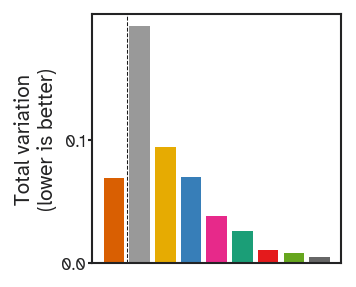

In [75]:
# plt.figure(figsize=viz.cm_to_inch((6, 6)), dpi=150)
fig = plt.figure(figsize=viz.cm_to_inch((6, 6)), dpi=150)
ax = fig.add_axes([0, 0, 1, 1])  # Will adjust position after setting size!

eta_lim_min = np.inf 
eta_lim_max = -np.inf
gamma_lim_min = np.inf
gamma_lim_max = -np.inf

combined_variability = {}

for mode in ["energy"] + ([i for i in all_dist_measures if i != "energy"]):
    normalized_etas = (distributions_etas[mode] - (-3)) / (8 - (-3))
    normalized_gammas = (distributions_gammas[mode] - (-0.1)) / (1 - (-0.1))

    std_normalized_eta = normalized_etas.std()
    std_normalized_gamma = normalized_gammas.std()
    
    combined_var = std_normalized_eta**2 + std_normalized_gamma**2

    combined_variability[mode] = combined_var


# Sort 
pair_energy = ("energy", combined_variability.pop("energy"))
sorted_combined_variability = [pair_energy] + sorted(combined_variability.items(), key=lambda x: x[1])[::-1]  # if x[0] !=
# 
for (mode, var) in sorted_combined_variability: # reverse=True):
    print(var)
    plt.bar(mode, var, color=metric_colors[mode])
    
# plt.xticks(ticks=all_dist_measures, labels=[method_names[m] for m in all_dist_measures], rotation=90)
plt.xticks([])

# get current y-tick locations
y_ticks = plt.yticks()[0]
print(y_ticks)
# plt.yticks([y_ticks.min(), y_ticks.max()])
plt.yticks([0, 0.1])
plt.ylabel("Total variation\n(lower is better)")

# TODO: Vertical line between the first and the remaining bars 
plt.axvline(x=0.5, linestyle="--", linewidth=0.5, color="k")

# Set the axes size to exactly 6x6 cm
ax_width_inch, ax_height_inch = viz.cm_to_inch((6, 6))
# fig.set_size_inches(ax_width_inch + 1, ax_height_inch + 1)  # Add margin for labels
ax.set_position([0.15, 0.15, ax_width_inch/(ax_width_inch + 1), 
                 ax_height_inch/(ax_height_inch + 1)])

# plt.tight_layout()
plt.savefig(output_path/ "total_variation_of_minima.pdf", bbox_inches='tight')
print(output_path / "total_variation_of_minima.pdf")

/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/gnm/hcp_schaefer_100_dataset/105_distance_metrics_mst_animal_0/ground_truth_analysis/minimums_for_top_8.pdf


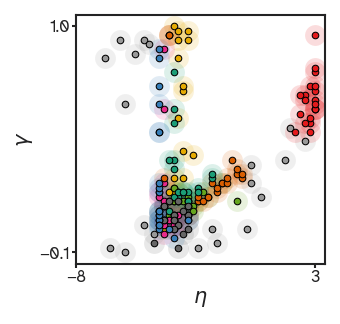

In [76]:
fig = plt.figure(dpi=150, figsize=viz.cm_to_inch((6,6))) 
ax = fig.add_axes([0, 0, 1, 1])  # Will adjust position after setting size!

for mode in all_dist_measures:
    x = distributions_etas[mode]
    y = distributions_gammas[mode]
    c = metric_colors[mode]

    # --- blur / glow layer ---
    ax.scatter(
        x, y,
        color=c,
        s=100,          # much larger
        alpha=0.15,    # very transparent
        linewidth=0,
        zorder=1
    )

    # --- sharp dots on top ---
    ax.scatter(
        x, y,
        color=c,
        label=method_names[mode],
        s=10,
        edgecolor='black',
        linewidth=0.5,
        zorder=2
    )
    
plt.xticks([-8,3])
plt.yticks([-0.1,1])
plt.ylabel(r"$\gamma$")
plt.xlabel(r"$\eta$")

ax_width_inch, ax_height_inch = viz.cm_to_inch((6, 6))
# fig.set_size_inches(ax_width_inch + 1, ax_height_inch + 1)  # Add margin for labels
ax.set_position([0.15, 0.15, ax_width_inch/(ax_width_inch + 1), 
                 ax_height_inch/(ax_height_inch + 1)])

plt.savefig(output_path / "minimums_for_top_8.pdf", bbox_inches='tight')
print(output_path / "minimums_for_top_8.pdf")

/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/gnm/hcp_schaefer_100_dataset/105_distance_metrics_mst_animal_0/ground_truth_analysis/minimums_for_top_8_mini.pdf


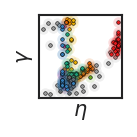

In [77]:
fig = plt.figure(dpi=150, figsize=viz.cm_to_inch((2,2))) 
ax = fig.add_axes([0, 0, 1, 1])  # Will adjust position after setting size!

for mode in all_dist_measures:
    x = distributions_etas[mode]
    y = distributions_gammas[mode]
    c = metric_colors[mode]

    # --- blur / glow layer ---
    ax.scatter(
        x, y,
        color=c,
        s=25,          # much larger
        alpha=0.15,    # very transparent
        linewidth=0,
        zorder=1
    )

    # --- sharp dots on top ---
    ax.scatter(
        x, y,
        color=c,
        label=method_names[mode],
        s=3,
        edgecolor='black',
        linewidth=0.25,
        # zorder=2
    )
    
# plt.xticks([-8,3])
# plt.yticks([-0.1,1])
plt.xticks([])
plt.yticks([])
plt.ylabel(r"$\gamma$")
plt.xlabel(r"$\eta$")

ax_width_inch, ax_height_inch = viz.cm_to_inch((6, 6))
# fig.set_size_inches(ax_width_inch + 1, ax_height_inch + 1)  # Add margin for labels
ax.set_position([0.15, 0.15, ax_width_inch/(ax_width_inch + 1), 
                 ax_height_inch/(ax_height_inch + 1)])

plt.savefig(output_path / "minimums_for_top_8_mini.pdf", bbox_inches='tight')
print(output_path / "minimums_for_top_8_mini.pdf")

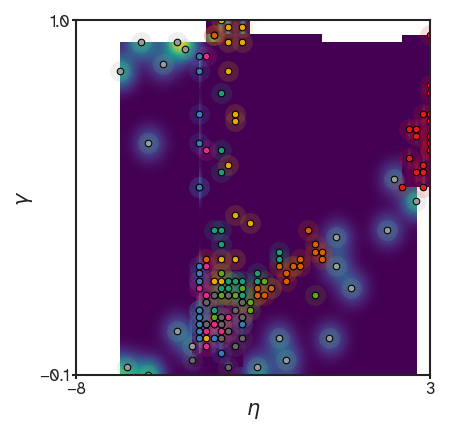

In [78]:
from scipy.ndimage import gaussian_filter

fig = plt.figure(dpi=150, figsize=viz.cm_to_inch((6,6))) 
ax = fig.add_axes([0, 0, 1, 1])  # Will adjust position after setting size!

for mode in all_dist_measures:
    x = distributions_etas[mode]
    y = distributions_gammas[mode]
    c = metric_colors[mode]

    # --- blur / glow layer ---
    ax.scatter(
        x, y,
        color=c,
        s=100,          # much larger
        alpha=0.15,    # very transparent
        linewidth=0,
        zorder=1
    )
    
    
    # Create a 2D histogram
    hist, xedges, yedges = np.histogram2d(x, y, bins=300)
    # Apply Gaussian blur
    hist_blurred = gaussian_filter(hist, sigma=10)
    # Plot as heatmap
    plt.imshow(hist_blurred.T, origin='lower', extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]], 
            cmap='viridis', aspect='auto')



    # --- sharp dots on top ---
    ax.scatter(
        x, y,
        color=c,
        label=method_names[mode],
        s=10,
        edgecolor='black',
        linewidth=0.5,
        zorder=2
    )
    
plt.xticks([-8,3])
plt.yticks([-0.1,1])
plt.ylabel(r"$\gamma$")
plt.xlabel(r"$\eta$")

ax_width_inch, ax_height_inch = viz.cm_to_inch((6, 6))
fig.set_size_inches(ax_width_inch + 1, ax_height_inch + 1)  # Add margin for labels
ax.set_position([0.15, 0.15, ax_width_inch/(ax_width_inch + 1), 
                 ax_height_inch/(ax_height_inch + 1)])

# plt.savefig(output_path / "minimums_for_top_8.pdf", bbox_inches='tight')
# print(output_path / "minimums_for_top_8.pdf")

In [79]:
# Human distributions 
# Lexi 
# human_connectomes = np.load("/Users/adrian/Documents/01_projects/14_4D_lab/connectome_distances/data/preprocessed/lexis_data/01_connectomes/00_individual_connectomes_bin.npy")
# distance_matrix = np.load("/Users/adrian/Documents/01_projects/14_4D_lab/connectome_distances/data/preprocessed/lexis_data/02_distance_matrices/distance_matrix_100.npy")

# HCP
human_connectomes = np.load("/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/data/preprocessed/hcp_schaefer_100_dataset/01_connectomes/00_connectomes_density10.npy")
distance_matrix = np.load("/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/data/preprocessed/hcp_schaefer_100_dataset/02_distance_matrices/distance_matrix_100.npy")


all_degrees = []
all_distances = []

for A in human_connectomes: 
    # Calculate degree for each node
    degrees = np.sum(A, axis=1)
    all_degrees.extend(degrees)
    
    # get all distances, remove zeros 
    distances_for_this_network = (distance_matrix*A).flatten()
    all_distances.extend(distances_for_this_network[distances_for_this_network > 0])

# Convert to numpy array
human_degrees = np.array(all_degrees)
human_distances = np.array(all_distances)

distributions_distances['human'] = human_distances
distributions_degree['human'] = human_degrees

human_distances

array([ 44.18144407,  32.06243908,  43.9089968 , ...,  17.08800749,
       104.42221986,  16.61324773])

/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/gnm/hcp_schaefer_100_dataset/105_distance_metrics_mst_animal_0/ground_truth_analysis/top20_networks_distance_distributions.pdf


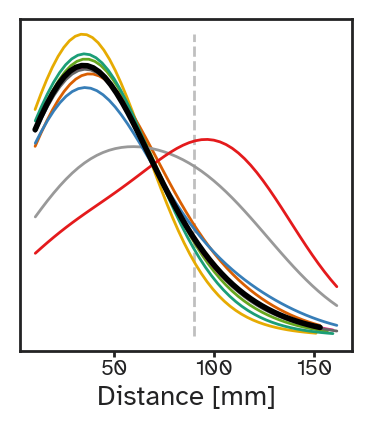

In [80]:
import scipy.ndimage as ndimage

# plot degree distributions (smoothed) 
fig = plt.figure(figsize=viz.cm_to_inch((6, 6)), dpi=200)
ax = fig.add_axes([0, 0, 1, 1])  # Will adjust position after setting size!

max_value_for_line = 0 

for mode, distances in distributions_distances.items():
    
    if mode not in all_dist_measures and not mode == 'human': 
        continue
    
    # Create histogram to get counts
    number_bins = 50
    counts, bins = np.histogram(distances, bins=number_bins, density=True)
    bin_centers = (bins[:-1] + bins[1:]) / 2
    
    # Add padding to bin_centers (linear expansion)
    bin_centers = np.array([bins[0] - (bins[1]-bins[0])*i for i in range(20,0,-1)] + list(bin_centers) + 
                           [bins[-1] + (bins[1]-bins[0])*i for i in range(1,21)])

    # padded_counts = []
    # for count in counts: 
    count = np.array([0]*20 + list(counts) + [0]*20)
    count = ndimage.gaussian_filter1d(count, sigma=10) 
    #     padded_counts.append(count)

    if count.max() > max_value_for_line:
        max_value_for_line = count.max()
        ax.vlines(x=90, 
                  ymin=0, ymax=max_value_for_line, 
                  color="gray", 
                  linestyle='--', alpha=0.5)

    # # Smooth the histogram with Gaussian filter
    # # smoothed_counts = ndimage.gaussian_filter1d(padded_counts, sigma=10) # 2
    
        # Plot smoothed curve
    ax.plot(bin_centers[20:-20], 
            count[20:-20],
            label=method_names[mode] if mode != 'human' else 'Human Connectomes',
            color=metric_colors[mode] if mode != 'human' else 'black',
            linewidth=2 if mode == "human" else 1
            )

plt.xlabel('Distance [mm]')
plt.ylabel("")
# plt.legend(fontsize=8, bbox_to_anchor=(1, 1), frameon=False)
plt.yticks([]) # 0,0.012])
    
ax_width_inch, ax_height_inch = viz.cm_to_inch((6, 6))
# fig.set_size_inches(ax_width_inch + 1, ax_height_inch + 1)  # Add margin for labels
ax.set_position([0.15, 0.15, ax_width_inch/(ax_width_inch + 1), 
                 ax_height_inch/(ax_height_inch + 1)])



plt.savefig(output_path / "top20_networks_distance_distributions.pdf", bbox_inches='tight')
print(output_path / "top20_networks_distance_distributions.pdf")
plt.show()

/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/gnm/hcp_schaefer_100_dataset/105_distance_metrics_mst_animal_0/ground_truth_analysis/top20_networks_degree_distributions.pdf


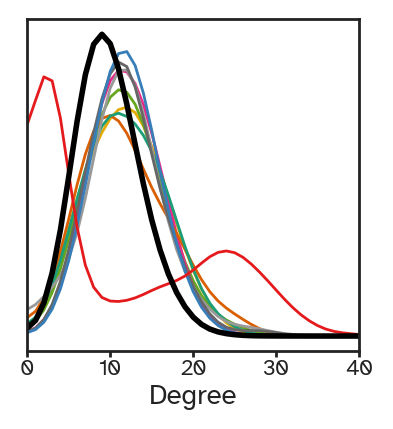

In [81]:
import scipy.ndimage as ndimage

# plot degree distributions (smoothed) 
fig = plt.figure(figsize=viz.cm_to_inch((6, 6)), dpi=200)
ax = fig.add_axes([0, 0, 1, 1])  # Will adjust position after setting size!

for mode, degrees in distributions_degree.items():
    
    if mode not in all_dist_measures and not mode == 'human': 
        continue
    
    # Create bins that always have steps of one and start quantity 0
    max_degree = 100
    bins = np.arange(0, max_degree + 2, step=1) - 0.5  # bins of width 1 centered on integers
    
    # Create histogram to get counts
    counts, bins = np.histogram(degrees, bins=bins, density=True)
    bin_centers = (bins[:-1] + bins[1:]) / 2
    
    count = ndimage.gaussian_filter1d(counts, sigma=2) 

    # Make all counts have a prob distribution
    # count /= np.sum(count)

    # Plot smoothed curve
    ax.plot(bin_centers,
            count,
            label=method_names[mode] if mode != 'human' else 'Human Connectomes',
            color=metric_colors[mode] if mode != 'human' else 'black',
            linewidth=1 if mode != 'human' else 2
            )

plt.xlim(0, 40)
    
plt.yticks([]) # 0, 0.1])
plt.xlabel('Degree')
plt.ylabel("")
# plt.legend()
ax_width_inch, ax_height_inch = viz.cm_to_inch((6, 6))
# fig.set_size_inches(ax_width_inch + 1, ax_height_inch + 1)  # Add margin for labels
ax.set_position([0.15, 0.15, ax_width_inch/(ax_width_inch + 1), 
                 ax_height_inch/(ax_height_inch + 1)])


plt.savefig(output_path / "top20_networks_degree_distributions.pdf", bbox_inches='tight')
print(output_path / "top20_networks_degree_distributions.pdf")
plt.show()

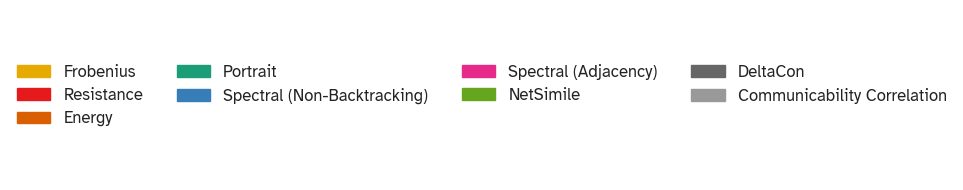

In [82]:
metric = "snr"
labels = {'snr': 'Signal-to-Noise Ratio'} # \n(higher = better)'}

fig = plt.figure(figsize=(10, 2))  # Adjust size as needed
ax = fig.add_subplot(111)

sorted_data = results_df[metric].sort_values()

# Create legend handles
handles = [patches.Patch(color=metric_colors[name],
                         label=method_names[name]) 
           for name in reversed(sorted_data.index) if metric_colors]

# Add legend
legend = ax.legend(handles=handles, loc='center', 
                   ncol=4, fontsize=12, 
                   frameon=False)

# Hide the axes
ax.axis('off')

plt.tight_layout()
plt.show()

# Degeneration

In [83]:
from typing import Dict, List

# Base directory for your chaos analysis results
dataset = "hcp_schaefer_100_dataset" # lexis_data
base_dir = f"/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/gnm/{dataset}/chaos_analysis"
output_dir = f"{base_dir}/plots"
Path(output_dir).mkdir(parents=True, exist_ok=True)


# degeneration_x_label_descriptor = "Degeneration Level\n(Consensus to Chaos)" # 'Step (0=Consensus -> Max=Chaos)'
# degeneration_x_label_descriptor = "Degeneration: Consensus to Chaos" # 'Step (0=Consensus -> Max=Chaos)'
degeneration_x_label_descriptor = "Increasing Degeneration" # : Consensus to Chaos" # 'Step (0=Consensus -> Max=Chaos)'


In [84]:
# metric = "snr"
# labels = {'snr': 'Signal-to-Noise Ratio'} # \n(higher = better)'}

# fig = plt.figure(figsize=(10, 1))  # Adjust size as needed
# ax = fig.add_subplot(111)

# sorted_data = results_df[metric] # .sort_values()

# # Create legend handles
# handles = [patches.Patch(color=metric_colors[name], label=method_names[name]) 
#            for name in reversed(sorted_data.index) if metric_colors]

# # Add legend
# legend = ax.legend(handles=handles, loc='center', 
#                    ncol=5, fontsize=12, 
#                    frameon=False)

# # Hide the axes
# ax.axis('off')

# plt.tight_layout()
# plt.savefig(output_path / "legend_chaos.pdf", bbox_inches='tight', pad_inches=0.1)
# print(output_path / "legend_chaos.pdf")
# plt.show()


Plotting comparison...
20200
frobenius
20200
net_simile
20200
spectral_distance_adjacency
20200
energy
20200
portrait
20200
communicability_corr
did comm corr
20200
delta_con
20200
netrd_non_backtracking_spectral
20200
resistance
Saved comparison plot to: /Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/gnm/hcp_schaefer_100_dataset/chaos_analysis/plots/chaos_comparison_all_metrics.pdf


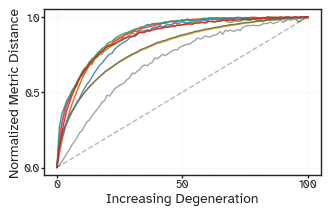

In [85]:

def plot_multiple_metrics_comparison(
    csv_paths: Dict[str, str],
    output_path: str = None,
    figsize_cm: tuple = (20, 12),
    normalize: bool = True
):
    """
    Compare multiple metrics on the same plot.
    """
    fig, ax = plt.subplots(figsize=viz.cm_to_inch(figsize_cm))
    
    for idx, (metric_name, csv_path) in enumerate(csv_paths.items()):
        # Load data
        df = pd.read_csv(csv_path)
        
        print(len(df))
        
        # Calculate mean trajectory
        df_summary = df.groupby('step')['metric_value'].agg(['mean', 'std']).reset_index()
            
            
        # Normalize if requested
        if normalize:
            min_val = df_summary['mean'].min()
            max_val = df_summary['mean'].max()
            if max_val > min_val:  # Avoid division by zero
                df_summary['mean_norm'] = (df_summary['mean'] - min_val) / (max_val - min_val)
                df_summary['std_norm'] = df_summary['std'] / (max_val - min_val)
                y_col = 'mean_norm'
                std_col = 'std_norm'
            else:
                y_col = 'mean'
                std_col = 'std'
        else:
            y_col = 'mean'
            std_col = 'std'
            
        print(metric_name)
        if metric_name == "communicability_corr":
            print("did comm corr")
            # Invert the values for communicability
            df_summary['mean'] = 1 - df_summary['mean']
            df_summary['mean_norm'] = 1 - df_summary['mean_norm']

        # Plot
        color = metric_colors[metric_name]
        ax.plot(
            df_summary['step'],
            df_summary[y_col],
            color=color,
            label=method_names[metric_name],
            alpha=0.9
        )

        # print(method_names[metric_name])
        # # Optional: add std band
        # ax.fill_between(
        #     df_summary['step'],
        #     df_summary[y_col] - df_summary[std_col],
        #     df_summary[y_col] + df_summary[std_col],
        #     alpha=0.15,
        #     color=color
        # )
    
    # Formatting
    ax.set_xlabel(degeneration_x_label_descriptor)
    if normalize:
        ax.set_ylabel('Normalized Metric Distance') # , fontsize=11)
    else:
        ax.set_ylabel('Metric Distance')

    # ax.set_title('Comparison of Metrics During Network Degradation', fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.3, linestyle='--', linewidth=0.5)
    
    # Add diagonal line for reference
    max_x = df_summary['step'].max()
    ax.plot([0, max_x], [0, 1], 'k--', alpha=0.3, linewidth=1)

    # plt.legend(fontsize=8, loc='upper left', bbox_to_anchor=(1,1))
    # plt.tight_layout()
    
            
    ax_width_inch, ax_height_inch = viz.cm_to_inch((9, 6))
    # fig.set_size_inches(ax_width_inch + 1, ax_height_inch + 1)  # Add margin for labels
    ax.set_position([0.15, 0.15, ax_width_inch/(ax_width_inch + 1), 
                    ax_height_inch/(ax_height_inch + 1)])

    
    if output_path:
        plt.savefig(output_path, dpi=300, bbox_inches='tight')
        print(f"Saved comparison plot to: {output_path}")
    else:
        plt.show()
    
    ax.set_yticks([0, 0.5, 1])
    ax.set_xticks([0, 50, 100])
    # plt.close()
    plt.show()
    
    return fig, ax



# Plot comparison of all metrics
print("\nPlotting comparison...")
csv_paths = {}
for metric in all_dist_measures: 
    csv_path = f"{base_dir}/chaos_analysis_{metric}.csv"
    if Path(csv_path).exists():
        csv_paths[metric] = csv_path

if csv_paths:
    plot_multiple_metrics_comparison(
        csv_paths=csv_paths,
        output_path=f"{output_dir}/chaos_comparison_all_metrics.pdf",
        # figsize_cm=(6,6), # 
        figsize_cm=(9,6), # 6),
        normalize=True
    )
    


# Degeneration II

In [93]:
from typing import Dict, List

# Base directory for your chaos analysis results
dataset = "hcp_schaefer_100_dataset" # lexis_data
base_dir = f"/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/gnm/{dataset}/chaos_analysis"
output_dir = f"{base_dir}/plots"
Path(output_dir).mkdir(parents=True, exist_ok=True)


# degeneration_x_label_descriptor = "Degeneration Level\n(Consensus to Chaos)" # 'Step (0=Consensus -> Max=Chaos)'
# degeneration_x_label_descriptor = "Degeneration: Consensus to Chaos" # 'Step (0=Consensus -> Max=Chaos)'
degeneration_x_label_descriptor = "Increasing Degeneration (%)" # : Consensus to Chaos" # 'Step (0=Consensus -> Max=Chaos)'



Plotting comparison...
Found chaos analysis for metric: frobenius
Found chaos analysis for metric: net_simile
Found chaos analysis for metric: spectral_distance_adjacency
Found chaos analysis for metric: energy
Found chaos analysis for metric: portrait
Found chaos analysis for metric: communicability_corr
Found chaos analysis for metric: delta_con
Found chaos analysis for metric: netrd_non_backtracking_spectral
Found chaos analysis for metric: resistance
Found chaos analysis for metric: hamming
20200
20200
20200
20200
20200
20200
did comm corr
20200
20200
20200
20200
Saved comparison plot to: /Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/gnm/hcp_schaefer_100_dataset/chaos_analysis/plots/chaos_comparison_all_metrics_plus_hamming.pdf


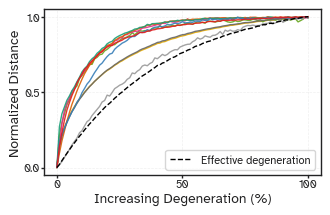

In [96]:

def plot_multiple_metrics_comparison(
    csv_paths: Dict[str, str],
    output_path: str = None,
    figsize_cm: tuple = (20, 12),
    normalize: bool = True
):
    """
    Compare multiple metrics on the same plot.
    """
    fig, ax = plt.subplots(figsize=viz.cm_to_inch(figsize_cm))
    
    for idx, (metric_name, csv_path) in enumerate(csv_paths.items()):
        # Load data
        df = pd.read_csv(csv_path)
        
        print(len(df))
        
        # Calculate mean trajectory
        df_summary = df.groupby('step')['metric_value'].agg(['mean', 'std']).reset_index()
            
            
        # Normalize if requested
        if normalize:
            min_val = df_summary['mean'].min()
            max_val = df_summary['mean'].max()
            if max_val > min_val:  # Avoid division by zero
                df_summary['mean_norm'] = (df_summary['mean'] - min_val) / (max_val - min_val)
                df_summary['std_norm'] = df_summary['std'] / (max_val - min_val)
                y_col = 'mean_norm'
                std_col = 'std_norm'
            else:
                y_col = 'mean'
                std_col = 'std'
        else:
            y_col = 'mean'
            std_col = 'std'
        
        
        # print(metric_name)
        color = metric_colors[metric_name]
        linestyle = '-'
        alpha = 0.9
        
        if metric_name == "communicability_corr":
            print("did comm corr")
            # Invert the values for communicability
            df_summary['mean'] = 1 - df_summary['mean']
            df_summary['mean_norm'] = 1 - df_summary['mean_norm']
            

        # Plot
        if metric_name != "hamming": 
            ax.plot(
                df_summary['step'],
                df_summary[y_col],
                color=color,
                # label=method_names[metric_name],
                alpha=alpha,
                linestyle=linestyle
            )
        elif metric_name == "hamming":
            color = "black"
            linestyle = "--"
            alpha = 1.0
            ax.plot(
                df_summary['step'],
                df_summary[y_col],
                color=color,
                label="Effective degeneration", # method_names[metric_name],
                alpha=alpha,
                linestyle=linestyle
            )
        else: 
            print("This metric does not exist: ", metric_name)
        # print(method_names[metric_name])
        # # Optional: add std band
        # ax.fill_between(
        #     df_summary['step'],
        #     df_summary[y_col] - df_summary[std_col],
        #     df_summary[y_col] + df_summary[std_col],
        #     alpha=0.15,
        #     color=color
        # )
    
    # Formatting
    ax.set_xlabel(degeneration_x_label_descriptor)
    if normalize:
        ax.set_ylabel('Normalized Distance') # , fontsize=11)
    else:
        ax.set_ylabel('Metric Distance')

    # ax.set_title('Comparison of Metrics During Network Degradation', fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.3, linestyle='--', linewidth=0.5)
    
    # Add diagonal line for reference
    # max_x = df_summary['step'].max()
    # ax.plot([0, max_x], [0, 1], 'k--', alpha=0.3, linewidth=1)
    
    # plt.legend(fontsize=8, loc='upper left', bbox_to_anchor=(1,1))
    plt.legend()
    # plt.tight_layout()
    
            
    ax_width_inch, ax_height_inch = viz.cm_to_inch((9, 6))
    # fig.set_size_inches(ax_width_inch + 1, ax_height_inch + 1)  # Add margin for labels
    ax.set_position([0.15, 0.15, ax_width_inch/(ax_width_inch + 1), 
                    ax_height_inch/(ax_height_inch + 1)])

    if output_path:
        plt.savefig(output_path, dpi=300, bbox_inches='tight')
        print(f"Saved comparison plot to: {output_path}")
    else:
        plt.show()
    
    ax.set_yticks([0, 0.5, 1])
    ax.set_xticks([0, 50, 100])
    # plt.close()
    plt.show()
    
    return fig, ax



# Plot comparison of all metrics
print("\nPlotting comparison...")
csv_paths = {}
metrics_for_here = all_dist_measures + ["hamming"]
for metric in metrics_for_here: 
    csv_path = f"{base_dir}/chaos_analysis_{metric}.csv"
    if Path(csv_path).exists():
        csv_paths[metric] = csv_path
        print(f"Found chaos analysis for metric: {metric}")

if csv_paths:
    plot_multiple_metrics_comparison(
        csv_paths=csv_paths,
        output_path=f"{output_dir}/chaos_comparison_all_metrics_plus_hamming.pdf",
        # figsize_cm=(6,6), # 
        figsize_cm=(9,6), # 6),
        normalize=True
    )
    



Saved comparison plot to: /Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/gnm/hcp_schaefer_100_dataset/chaos_analysis/plots/importance_degredation_random_all_metrics.pdf


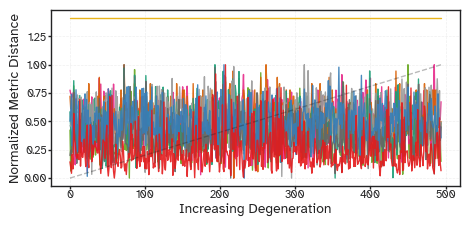

In [46]:
# /Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/gnm/lexis_data/importance_degradation_betweenness/importance_degradation_betweenness_hamming.csv

def plot_multiple_metrics_comparison(
    csv_paths: Dict[str, str],
    output_path: str = None,
    figsize_cm: tuple = (20, 12),
    normalize: bool = True
):
    """
    Compare multiple metrics on the same plot.
    """
    fig, ax = plt.subplots(figsize=viz.cm_to_inch(figsize_cm))
    
    
    for idx, (metric_name, csv_path) in enumerate(csv_paths.items()):
        # Load data
        df = pd.read_csv(csv_path)
        # print(pd.read_csv(csv_path))
        
        # Calculate mean trajectory
        df_summary = df.groupby('step')['metric_value'].agg(['mean', 'std']).reset_index()
        
        # Normalize if requested
        if normalize:
            min_val = df_summary['mean'].min()
            max_val = df_summary['mean'].max()
            if max_val > min_val:  # Avoid division by zero
                df_summary['mean_norm'] = (df_summary['mean'] - min_val) / (max_val - min_val)
                df_summary['std_norm'] = df_summary['std'] / (max_val - min_val)
                y_col = 'mean_norm'
                std_col = 'std_norm'
            else:
                y_col = 'mean'
                std_col = 'std'
        else:
            y_col = 'mean'
            std_col = 'std'
        
        # Plot
        color = metric_colors[metric_name]
        ax.plot(
            df_summary['step'],
            df_summary[y_col],
            color=color,
            label=method_names[metric_name],
            alpha=0.9
        )

        # print(method_names[metric_name])
        # # Optional: add std band
        # ax.fill_between(
        #     df_summary['step'],
        #     df_summary[y_col] - df_summary[std_col],
        #     df_summary[y_col] + df_summary[std_col],
        #     alpha=0.15,
        #     color=color
        # )
    
    # Formatting
    ax.set_xlabel(degeneration_x_label_descriptor)
    if normalize:
        ax.set_ylabel('Normalized Metric Distance') # , fontsize=11)
    else:
        ax.set_ylabel('Metric Distance')

    # ax.set_title('Comparison of Metrics During Network Degradation', fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.3, linestyle='--', linewidth=0.5)
    
    # Add diagonal line for reference
    max_x = df_summary['step'].max()
    ax.plot([0, max_x], [0, 1], 'k--', alpha=0.3, linewidth=1)

    # plt.legend(fontsize=8, loc='upper left', bbox_to_anchor=(1,1))
    plt.tight_layout()
    
    if output_path:
        plt.savefig(output_path, dpi=300, bbox_inches='tight')
        print(f"Saved comparison plot to: {output_path}")
    else:
        plt.show()
    
    
    # plt.close()
    plt.show()
    
    return fig, ax



# Plot comparison of all metrics

ranking_methods = ["betweenness", "random"]


for ranking_method in ranking_methods: 
    base_dir = f"/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/gnm/{dataset_name}/importance_degradation_{ranking_method}"
    
    csv_paths = {}
    for metric in all_dist_measures: 
        csv_path = f"{base_dir}/importance_degradation_{ranking_method}_{metric}.csv" # chaos_analysis_{metric}.csv"
        if Path(csv_path).exists():
            csv_paths[metric] = csv_path

    if csv_paths:
        plot_multiple_metrics_comparison(
            csv_paths=csv_paths,
            output_path=f"{output_dir}/importance_degredation_{ranking_method}_all_metrics.pdf",
            # figsize_cm=(6,6), # 
            figsize_cm=(12,6), # 6),
            normalize=True
        )
        


In [47]:
coords_file = "/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/data/raw/hcp_schaefer_100/Schaefer_100_MNI_coords.txt"
coords = np.loadtxt(coords_file)[:, :3]

495
99
495
99
495
99
495
99
495
99
495
99
495
99
495
99
/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/gnm/hcp_schaefer_100_dataset/105_distance_metrics_mst_animal_0/ground_truth_analysis/connectome_visualization_importance_degradation_random.pdf


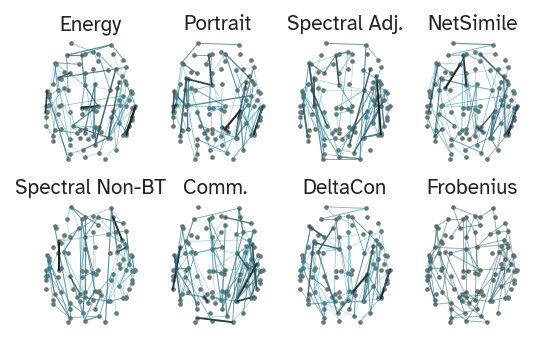

In [48]:
import matplotlib.colors as mcolors
from pathlib import Path

# =========================
# FIGURE SETUP
# =========================

fig, axes = plt.subplot_mosaic(
    [["A", "B", "C", "D"],
     ["E", "F", "G", "H"]],
    figsize=viz.cm_to_inch((9,6)),
    dpi=150
)

measures = [
    "energy",
    "portrait",
    "spectral_distance_adjacency",
    "net_simile",
    "netrd_non_backtracking_spectral",
    # "resistance",
    "communicability_corr",
    "delta_con",
    "frobenius",
]


method_names = {
    'portrait': 'Portrait', #  Divergence',
    'energy': 'Energy', #  Distance',
    'spectral_distance_adjacency': 'Spectral Adj.',
    'delta_con': 'DeltaCon',
    'frobenius': 'Frobenius', #  Distance',
    'resistance': 'Res.', #  Distance',
    'net_simile': 'NetSimile', #  Distance',
    "netrd_non_backtracking_spectral": "Spectral Non-BT", # NetRD Non-Backtracking Spectral",
    "communicability_corr": "Comm. ",
}


ax_labels = list("ABCDEFGH")
NODES = 100
AGG_FUNC = "mean"

base_dir = Path(
    f"/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/"
    f"output/gnm/{dataset_name}/importance_degradation_{ranking_method}"
)

IMPORTANCE_PATH = base_dir / f"edge_importance_{ranking_method}.csv"

# =========================
# COLORMAP (GLOBAL)
# =========================

color_strong = "#232324"
color_weak   = "#3FA5C454"

cmap = mcolors.LinearSegmentedColormap.from_list(
    "connection_cmap",
    [color_weak, color_strong]
)

# =========================
# FIRST PASS: BUILD CONNECTOMES
# =========================

connectomes = {}
all_weights = []

importance_df = pd.read_csv(IMPORTANCE_PATH)
importance_df["edge"] = importance_df["edge"].apply(eval)

ranked_edges = (
    importance_df
    .sort_values("importance", ascending=False)["edge"]
    .tolist()
)

step_to_edge = dict(enumerate(ranked_edges))

for measure in measures:
    results_path = base_dir / f"importance_degradation_{ranking_method}_{measure}.csv"
    df = pd.read_csv(results_path)

    df["edge"] = df["step"].map(step_to_edge)
    df[["i", "j"]] = pd.DataFrame(df["edge"].tolist(), index=df.index)
    
    # HACK that allows frobenius to be thresholded, too. 
    if measure == "frobenius": 
        # remove by random to mask 
        df["metric_value"] = np.random.rand(len(df))
    elif measure == "communicability_corr":
        # normalize: 
        df["metric_value"] = (df["metric_value"] - df["metric_value"].min()) / (df["metric_value"].max() - df["metric_value"].min())
        # Invert the values for communicability
        df["metric_value"] = 1 - df["metric_value"]

    edge_metric = (
        df
        .groupby(["i", "j"])["metric_value"]
        .agg(AGG_FUNC)
    )

    A = np.zeros((NODES, NODES))
    for (i, j), w in edge_metric.items():
        A[i, j] = w
        A[j, i] = w

    connectomes[measure] = A

    vals = A[np.tril_indices_from(A, k=-1)]
    all_weights.append(vals[vals > 0])


# =========================

TOP_PERCENT = 20.0  # percent of strongest edges to draw

for ax_label, measure in zip(ax_labels, measures):
    ax = axes[ax_label]
    connectome = connectomes[measure]

    ax.scatter(coords[:, 0], coords[:, 1], s=1.5)

    num_nodes = connectome.shape[0]


    # ---- extract lower-triangle edge weights ----
    tril_idx = np.tril_indices(num_nodes, k=-1)
    weights = connectome[tril_idx]

    # keep only positive edges
    mask = weights > 0
    weights = weights[mask]
    edges_i = tril_idx[0][mask]
    edges_j = tril_idx[1][mask]
    
    print(len(weights))

    if len(weights) == 0:
        continue

    # Threshold
    threshold = np.percentile(weights, 100 - TOP_PERCENT)
    # threshold = threshold * 0.99999  # slightly lower to include more edges
    strong_mask = weights >= threshold

    weights = weights[strong_mask]
    edges_i = edges_i[strong_mask]
    edges_j = edges_j[strong_mask]
    
    print(len(weights))

    # ---- per-subplot normalization (only over drawn edges) ----
    norm = mcolors.Normalize(
        vmin=weights.min(),
        vmax=weights.max()
    )

    # ---- draw edges ----
    for i, j, w in zip(edges_i, edges_j, weights):
        
        if measure != "frobenius": 
            ax.plot(
                [coords[i, 0], coords[j, 0]],
                [coords[i, 1], coords[j, 1]],
                color=cmap(norm(w)),
                alpha=norm(w)*2/4+0.5, 
                linewidth=norm(w)*3/4 + 0.25, # +0.25, # 0.25,
            )
        else:  # Frobenius
            ax.plot(
                [coords[i, 0], coords[j, 0]],
                [coords[i, 1], coords[j, 1]],
                color=cmap(1/2), # norm(w)),
                alpha=0.5, # norm(w)*3/4+0.25, 
                linewidth=0.5, # norm(w)*3/4, # +0.25, # 0.25,
            )
            
    ax.set_title(f"{method_names[measure]}") # .replace(" ", "\n")}") # ax_label}")
    ax.set_aspect("equal")
    ax.axis("off")

plt.tight_layout()

plt.savefig(
    output_path / f"connectome_visualization_importance_degradation_{ranking_method}.pdf",
    bbox_inches='tight',
    dpi=300
)
print(output_path / f'connectome_visualization_importance_degradation_{ranking_method}.pdf')



# PCA 

In [49]:
# Functions 



import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy import stats
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Configuration"
output_path = Path(base_path) / "method_evaluation"
output_path.mkdir(exist_ok=True)


def load_all_methods():
    """Load and combine all method data."""
    all_data_list = []
    loaded_methods = []
    
    for method in all_dist_measures:
        path = f"{base_path}/summary_indiv_{method}_for_exp_{experiment_name}.csv"
        try:
            df = pd.read_csv(path)
            metric_cols = [col for col in df.columns 
                          if col not in ["eta", "gamma", "network_index", "filename", "id"]]
            if metric_cols:
                df['metric_value'] = df[metric_cols[0]]
                df['method'] = method
                # Normalize metric_value to [0, 1]
                df["metric_value"] = (df["metric_value"] - df["metric_value"].min()) / (df["metric_value"].max() - df["metric_value"].min())
                
                # Turn similarities into distances for specific metrics
                if metric_cols[0] in ['Resistance_subject_0', 'Communicability_subject_0']: 
                    df["metric_value"] = 1 - df["metric_value"]
                    print("inverted" + metric_cols[0])
                print(metric_cols)
                
                all_data_list.append(df[['eta', 'gamma', 'id', 'metric_value', 'method']])
                loaded_methods.append(method)
                print(f"  ✓ Loaded {method}")
        except FileNotFoundError:
            print(f"  ✗ File not found for {method}")
    
    all_data = pd.concat(all_data_list, ignore_index=True)
    
    # Create wide format
    wide_data = all_data.pivot_table(
        index=['eta', 'gamma', 'id'],
        columns='method',
        values='metric_value'
    ).reset_index()
    
    return wide_data, loaded_methods


def normalize_methods(data, methods):
    """Normalize each method to [0, 1] range."""
    normalized = data.copy()
    for method in methods:
        min_val = data[method].min()
        max_val = data[method].max()
        if max_val > min_val:
            normalized[method] = (data[method] - min_val) / (max_val - min_val)
    return normalized


# ============================================================================
# STRATEGY 1: CONSENSUS-BASED APPROACHES
# ============================================================================

def consensus_approaches(data, methods):
    """Calculate different consensus measures."""
    print("\n" + "="*70)
    print("STRATEGY 1: CONSENSUS-BASED GROUND TRUTH")
    print("="*70)
    
    results = {}
    
    # Normalize first
    norm_data = normalize_methods(data, methods)
    
    # 1. Mean consensus (ensemble average)
    norm_data['consensus_mean'] = norm_data[methods].mean(axis=1)
    
    # 2. Median consensus (robust to outliers)
    norm_data['consensus_median'] = norm_data[methods].median(axis=1)
    
    # 3. Trimmed mean (remove top/bottom 10%)
    norm_data['consensus_trimmed'] = norm_data[methods].apply(
        lambda x: stats.trim_mean(x.dropna(), 0.1), axis=1
    )
    
    # Calculate correlations with each consensus
    for consensus_type in ['mean', 'median', 'trimmed']:
        col = f'consensus_{consensus_type}'
        print(f"\nCorrelations with {consensus_type.upper()} consensus:")
        corrs = {}
        for method in methods:
            corr = norm_data[method].corr(norm_data[col])
            corrs[method] = corr
            print(f"  {method:30s}: {corr:.4f}")
        results[consensus_type] = corrs
    
    # Save
    consensus_df = pd.DataFrame(results).T
    consensus_df.to_csv(output_path / 'consensus_correlations.csv')
    
    return norm_data, results


# ============================================================================
# STRATEGY 2: INTER-METHOD AGREEMENT
# ============================================================================

def inter_method_agreement(data, methods):
    """Calculate how well each method agrees with all others."""
    print("\n" + "="*70)
    print("STRATEGY 2: INTER-METHOD AGREEMENT")
    print("="*70)
    
    norm_data = normalize_methods(data, methods)
    
    # Calculate average correlation with all other methods
    agreement_scores = {}
    for method1 in methods:
        corrs = []
        for method2 in methods:
            if method1 != method2:
                corr = norm_data[method1].corr(norm_data[method2])
                if not np.isnan(corr):
                    corrs.append(corr)
        agreement_scores[method1] = np.mean(corrs) if corrs else 0
    
    print("\nAverage agreement with other methods:")
    for method, score in sorted(agreement_scores.items(), key=lambda x: x[1], reverse=True):
        print(f"  {method:30s}: {score:.4f}")
    
    # Plot
    sorted_methods = sorted(agreement_scores.keys(), key=lambda x: agreement_scores[x], reverse=True)
    values = [agreement_scores[m] for m in sorted_methods]
    
    pd.DataFrame({'method': list(agreement_scores.keys()), 
                  'agreement_score': list(agreement_scores.values())}).to_csv(
        output_path / 'inter_method_agreement.csv', index=False)
    
    return agreement_scores


# ============================================================================
# STRATEGY 3: PCA-BASED APPROACH
# ============================================================================

def pca_approach(data, methods):
    """Use PCA to find the main component across methods."""
    print("\n" + "="*70)
    print("STRATEGY 3: PCA-BASED APPROACH")
    print("="*70)
    
    norm_data = normalize_methods(data, methods)
    
    # Prepare data (remove NaNs)
    X = norm_data[methods].dropna()
    
    # Standardize
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    # PCA
    pca = PCA()
    X_pca = pca.fit_transform(X_scaled)
    
    print(f"\nExplained variance by component:")
    for i, var in enumerate(pca.explained_variance_ratio_[:5]):
        print(f"  PC{i+1}: {var:.4f} ({var*100:.2f}%)")
    print(f"  Cumulative (first 3): {pca.explained_variance_ratio_[:3].sum():.4f}")
    
    # Loadings (how much each method contributes to PC1)
    loadings = pd.DataFrame(
        pca.components_.T,
        columns=[f'PC{i+1}' for i in range(len(methods))],
        index=methods
    )
    
    print(f"\nPC1 Loadings (main component):")
    for method, loading in loadings['PC1'].abs().sort_values(ascending=False).items():
        print(f"  {method:30s}: {loadings.loc[method, 'PC1']:7.4f} (|{loading:.4f}|)")
    
    # Save
    loadings.to_csv(output_path / 'pca_loadings.csv')
    
    # Calculate correlation of each method with PC1
    pc1_scores = X_pca[:, 0]
    pc1_correlations = {}
    for i, method in enumerate(methods):
        pc1_correlations[method] = np.corrcoef(X[method], pc1_scores)[0, 1]
    
    return loadings, pca, pc1_correlations


# ============================================================================
# STRATEGY 4: COEFFICIENT OF VARIATION (STABILITY)
# ============================================================================

def stability_analysis(data, methods):
    """Analyze which methods have more stable/consistent values."""
    print("\n" + "="*70)
    print("STRATEGY 4: STABILITY ANALYSIS")
    print("="*70)
    
    norm_data = normalize_methods(data, methods)
    
    stability_metrics = {}
    
    for method in methods:
        values = norm_data[method].dropna()
        stability_metrics[method] = {
            'cv': values.std() / values.mean() if values.mean() != 0 else np.inf,  # Coefficient of variation
            'iqr': values.quantile(0.75) - values.quantile(0.25),  # Interquartile range
            'range': values.max() - values.min(),
            'mad': np.median(np.abs(values - values.median()))  # Median absolute deviation
        }
    
    print("\nStability metrics (lower = more stable/consistent):")
    print("\nCoefficient of Variation (CV):")
    for method, metrics in sorted(stability_metrics.items(), key=lambda x: x[1]['cv']):
        print(f"  {method:30s}: {metrics['cv']:.4f}")
    
    pd.DataFrame(stability_metrics).T.to_csv(output_path / 'stability_metrics.csv')
    
    return stability_metrics


# ============================================================================
# SUMMARY REPORT
# ============================================================================

def create_summary_report(consensus_results, agreement_scores, pc1_correlations, stability_metrics):
    """Create a comprehensive summary ranking methods."""
    print("\n" + "="*70)
    print("COMPREHENSIVE SUMMARY")
    print("="*70)
    
    methods = list(agreement_scores.keys())
    
    summary = pd.DataFrame(index=methods)
    
    # Add consensus correlations
    summary['consensus_mean'] = [consensus_results['mean'][m] for m in methods]
    summary['consensus_median'] = [consensus_results['median'][m] for m in methods]
    
    # Add inter-method agreement
    summary['inter_method_agreement'] = [agreement_scores[m] for m in methods]
    
    # Add PC1 correlation (absolute value)
    summary['pc1_correlation'] = [abs(pc1_correlations[m]) for m in methods]
    
    # Add stability (inverse CV, so higher = better)
    summary['stability'] = [1 / (stability_metrics[m]['cv'] + 0.01) for m in methods]
    
    # Normalize all metrics to [0, 1]
    for col in summary.columns:
        min_val = summary[col].min()
        max_val = summary[col].max()
        if max_val > min_val:
            summary[col] = (summary[col] - min_val) / (max_val - min_val)
    
    # Calculate composite score (equal weighting)
    summary['composite_score'] = summary.mean(axis=1)
    
    # Rank
    summary['rank'] = summary['composite_score'].rank(ascending=False)
    
    # Sort by composite score
    summary = summary.sort_values('composite_score', ascending=False)
    
    print("\nFINAL RANKING (by composite score):")
    print(summary.to_string())
    
    summary.to_csv(output_path / 'method_ranking_summary.csv')
    
    return summary

['Frobenius_subject_0']
  ✓ Loaded frobenius
['Net_simile_subject_0']
  ✓ Loaded net_simile
['SpectralDist_adjacency_subject_0']
  ✓ Loaded spectral_distance_adjacency
['MaxCrit_subject_0']
  ✓ Loaded energy
['PortraitDiv_subject_0']
  ✓ Loaded portrait
['CommCorr_subject_0']
  ✓ Loaded communicability_corr
['DeltaCon_subject_0']
  ✓ Loaded delta_con
['Netrd_non_backtracking_spectral_subject_0']
  ✓ Loaded netrd_non_backtracking_spectral
invertedResistance_subject_0
['Resistance_subject_0']
  ✓ Loaded resistance
/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/gnm/hcp_schaefer_100_dataset/105_distance_metrics_mst_animal_0/method_evaluation/pca_analysis_scree.pdf


/opt/miniconda3/envs/ma_thesis/lib/python3.13/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: divide by zero encountered in matmul
  X_transformed = X @ self.components_.T
/opt/miniconda3/envs/ma_thesis/lib/python3.13/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: overflow encountered in matmul
  X_transformed = X @ self.components_.T
/opt/miniconda3/envs/ma_thesis/lib/python3.13/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: invalid value encountered in matmul
  X_transformed = X @ self.components_.T


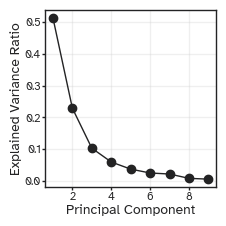

In [50]:


# STRATEGY 3: PCA-BASED APPROACH
"""Use PCA to find the main component across methods."""

# Load data
data, methods = load_all_methods()
norm_data = normalize_methods(data, methods)

# Prepare data (remove NaNs)
X = norm_data[methods].dropna()

# Standardize
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# PCA
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

# Loadings (how much each method contributes to PC1)
loadings = pd.DataFrame(
    pca.components_.T,
    columns=[f'PC{i+1}' for i in range(len(methods))],
    index=methods
)

# Save
loadings.to_csv(output_path / 'pca_loadings.csv')

# Plot loadings
fig, ax = plt.subplots(1, 1, figsize=viz.cm_to_inch((6,6))) # (16, 6))

# PC1 loadings
sorted_methods = loadings['PC1'].abs().sort_values(ascending=False).index
values = [loadings.loc[m, 'PC1'] for m in sorted_methods]
colors = [halfblack for v in values] # '#10b981' if v > 0 else '#ef4444' for v in values]

sorted_methods_pc1 = sorted_methods.copy()


# Scree plot
ax.plot(range(1, len(pca.explained_variance_ratio_) + 1), 
                pca.explained_variance_ratio_, 'o-', # linewidth=2, 
                # markersize=8, 
                color=halfblack) 
ax.set_xlabel('Principal Component') # , fontsize=11)
ax.set_ylabel('Explained Variance Ratio') # , fontsize=11)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(output_path / 'pca_analysis_scree.pdf', bbox_inches='tight')
print(output_path / 'pca_analysis_scree.pdf')
plt.show()

# Calculate correlation of each method with PC1
pc1_scores = X_pca[:, 0]
pc1_correlations = {}
for i, method in enumerate(methods):
    pc1_correlations[method] = np.corrcoef(X[method], pc1_scores)[0, 1]


['Frobenius_subject_0']
  ✓ Loaded frobenius
['Net_simile_subject_0']
  ✓ Loaded net_simile
['SpectralDist_adjacency_subject_0']
  ✓ Loaded spectral_distance_adjacency
['MaxCrit_subject_0']
  ✓ Loaded energy
['PortraitDiv_subject_0']
  ✓ Loaded portrait
['CommCorr_subject_0']
  ✓ Loaded communicability_corr
['DeltaCon_subject_0']
  ✓ Loaded delta_con
['Netrd_non_backtracking_spectral_subject_0']
  ✓ Loaded netrd_non_backtracking_spectral
invertedResistance_subject_0
['Resistance_subject_0']
  ✓ Loaded resistance
/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/gnm/hcp_schaefer_100_dataset/105_distance_metrics_mst_animal_0/method_evaluation/pca_analysis_scree.pdf


/opt/miniconda3/envs/ma_thesis/lib/python3.13/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: divide by zero encountered in matmul
  X_transformed = X @ self.components_.T
/opt/miniconda3/envs/ma_thesis/lib/python3.13/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: overflow encountered in matmul
  X_transformed = X @ self.components_.T
/opt/miniconda3/envs/ma_thesis/lib/python3.13/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: invalid value encountered in matmul
  X_transformed = X @ self.components_.T


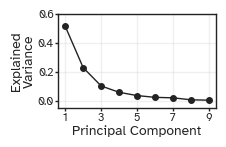

In [51]:


# STRATEGY 3: PCA-BASED APPROACH
"""Use PCA to find the main component across methods."""

# Load data
data, methods = load_all_methods()
norm_data = normalize_methods(data, methods)

# Prepare data (remove NaNs)
X = norm_data[methods].dropna()

# Standardize
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# PCA
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

# Loadings (how much each method contributes to PC1)
loadings = pd.DataFrame(
    pca.components_.T,
    columns=[f'PC{i+1}' for i in range(len(methods))],
    index=methods
)

# Save
loadings.to_csv(output_path / 'pca_loadings.csv')

# Plot loadings
fig, ax = plt.subplots(1, 1, figsize=viz.cm_to_inch((6,4))) # (16, 6))

# PC1 loadings
sorted_methods = loadings['PC1'].abs().sort_values(ascending=False).index
values = [loadings.loc[m, 'PC1'] for m in sorted_methods]
colors = [halfblack for v in values] # '#10b981' if v > 0 else '#ef4444' for v in values]

sorted_methods_pc1 = sorted_methods.copy()


# Scree plot
ax.plot(range(1, len(pca.explained_variance_ratio_) + 1), 
                pca.explained_variance_ratio_, 'o-', # linewidth=2, 
                markersize=4, 
                color=halfblack) 
ax.set_xlabel('Principal Component') # , fontsize=11)
ax.set_ylabel('Explained\nVariance') # iance Ratio') # , fontsize=11)
ax.set_xticks(range(1, len(pca.explained_variance_ratio_) + 1, 2))
ax.set_ylim(-0.05, 0.6)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(output_path / 'pca_analysis_scree.pdf', bbox_inches='tight')
print(output_path / 'pca_analysis_scree.pdf')
plt.show()

# Calculate correlation of each method with PC1
pc1_scores = X_pca[:, 0]
pc1_correlations = {}
for i, method in enumerate(methods):
    pc1_correlations[method] = np.corrcoef(X[method], pc1_scores)[0, 1]


['Frobenius_subject_0']
  ✓ Loaded frobenius
['Net_simile_subject_0']
  ✓ Loaded net_simile
['SpectralDist_adjacency_subject_0']
  ✓ Loaded spectral_distance_adjacency
['MaxCrit_subject_0']
  ✓ Loaded energy
['PortraitDiv_subject_0']
  ✓ Loaded portrait
['CommCorr_subject_0']
  ✓ Loaded communicability_corr
['DeltaCon_subject_0']
  ✓ Loaded delta_con
['Netrd_non_backtracking_spectral_subject_0']
  ✓ Loaded netrd_non_backtracking_spectral
invertedResistance_subject_0
['Resistance_subject_0']
  ✓ Loaded resistance
PC1 Loadings (Explains 51.4% of variance)
Index(['spectral_distance_adjacency', 'net_simile', 'portrait', 'frobenius',
       'delta_con', 'energy', 'netrd_non_backtracking_spectral',
       'communicability_corr', 'resistance'],
      dtype='object')
PC2 Loadings (Explains 22.9% of variance)
['spectral_distance_adjacency', 'net_simile', 'portrait', 'frobenius', 'delta_con', 'energy', 'netrd_non_backtracking_spectral', 'communicability_corr', 'resistance']
/Users/adrian/Documen

/opt/miniconda3/envs/ma_thesis/lib/python3.13/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: divide by zero encountered in matmul
  X_transformed = X @ self.components_.T
/opt/miniconda3/envs/ma_thesis/lib/python3.13/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: overflow encountered in matmul
  X_transformed = X @ self.components_.T
/opt/miniconda3/envs/ma_thesis/lib/python3.13/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: invalid value encountered in matmul
  X_transformed = X @ self.components_.T


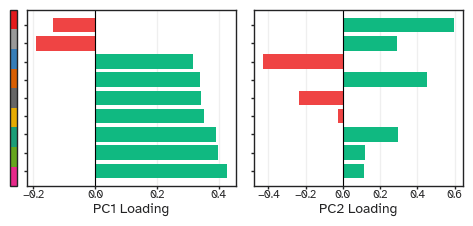

In [52]:
# PCA 

# Load data
data, methods = load_all_methods()
norm_data = normalize_methods(data, methods)

# Prepare data (remove NaNs)
X = norm_data[methods].dropna()

# Standardize
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# PCA
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

# Loadings (how much each method contributes to PC1)
loadings = pd.DataFrame(
    pca.components_.T,
    columns=[f'PC{i+1}' for i in range(len(methods))],
    index=methods
)
loadings.to_csv(output_path / 'pca_loadings.csv')

# Plot loadings
fig, axes = plt.subplots(1, 2, figsize=viz.cm_to_inch((12,6))) # (16, 6))

# PC1 loadings
sorted_methods = loadings['PC1'].abs().sort_values(ascending=False).index
values = [loadings.loc[m, 'PC1'] for m in sorted_methods]
# colors = [halfblack for v in values] 
colors= ['#10b981' if v > 0 else '#ef4444' for v in values]

sorted_methods_pc1 = sorted_methods.copy()


# PC1 
axes[0].barh(range(len(sorted_methods)), values, color=colors) # , labels=sorted_methods)
axes[0].set_yticks(range(len(sorted_methods)))
# axes[0].set_yticklabels([m.replace('_', ' ').title() for m in sorted_methods]) # , fontsize=9)
axes[0].set_xlabel('PC1 Loading') # , fontsize=11)
# axes[0].set_title(f'PC1 Loadings (Explains {pca.explained_variance_ratio_[0]*100:.1f}% of variance)') # , 
                    # fontsize=12, fontweight='bold')
print(f'PC1 Loadings (Explains {pca.explained_variance_ratio_[0]*100:.1f}% of variance)')
axes[0].axvline(x=0, color='black', linewidth=0.8)
axes[0].grid(axis='x', alpha=0.3)

axes[0].set_yticklabels([])

# PC2
print(sorted_methods)
values = [loadings.loc[m, 'PC2'] for m in sorted_methods]
# colors = [halfblack for v in values] # '#10b981' if v > 0 else '#ef4444' for v in values]#
colors= ['#10b981' if v > 0 else '#ef4444' for v in values]

axes[1].barh(range(len(sorted_methods)), values, color=colors) # , labels=sorted_methods)
axes[1].set_yticks(range(len(sorted_methods)))
# axes[0].set_yticklabels([m.replace('_', ' ').title() for m in sorted_methods]) # , fontsize=9)
axes[1].set_xlabel('PC2 Loading') # , fontsize=11)
# axes[0].set_title(f'PC1 Loadings (Explains {pca.explained_variance_ratio_[0]*100:.1f}% of variance)') # , 
                    # fontsize=12, fontweight='bold')
print(f'PC2 Loadings (Explains {pca.explained_variance_ratio_[1]*100:.1f}% of variance)')
axes[1].axvline(x=0, color='black', linewidth=0.8)
axes[1].grid(axis='x', alpha=0.3)

axes[1].set_yticklabels([])


plt.tight_layout()

# Get positions AFTER setting up the plot
heatmap_pos = axes[0].get_position()
highest_pos = heatmap_pos.y1
lowest_pos = heatmap_pos.y0
leftest_pos = heatmap_pos.x0
rightest_pos = heatmap_pos.x1

# Get positions AFTER setting up heatmap
heatmap_pos = axes[0].get_position()
highest_pos = heatmap_pos.y1
lowest_pos = heatmap_pos.y0
leftest_pos = heatmap_pos.x0
rightest_pos = heatmap_pos.x1

# Add left colorbar (method colors)
thickness_bars = 0.015 # 3
distance_between_bar_and_corr_heatmap = 0.02 # 0.03 for 6,6

print([m for m in sorted_methods])
# plt.cm.colors.ListedColormap(colors_for_legend)

colors_for_legend = [metric_colors[m] for m in sorted_methods] 
# cax = fig.add_axes([leftest_pos - thickness_bars - distance_between_bar_and_corr_heatmap -0.075, # 5, 
#                     lowest_pos +0.1, 
#                     thickness_bars, 
#                     highest_pos - lowest_pos - 0.05])
cax = fig.add_axes([leftest_pos - thickness_bars - distance_between_bar_and_corr_heatmap, #  -0.075, # 5, 
                    lowest_pos, #  +0.1, 
                    thickness_bars, 
                    highest_pos - lowest_pos]) #  - 0.05])
norm = plt.Normalize(vmin=0, vmax=len(all_dist_measures))
sm = plt.cm.ScalarMappable(cmap=plt.cm.colors.ListedColormap(colors_for_legend), norm=norm)
cb = plt.colorbar(sm, cax=cax)
cb.set_ticks(ticks=[], labels=[])
cb.ax.yaxis.set_ticks_position('left')
cb.ax.yaxis.set_label_position('left')

plt.savefig(output_path / 'pca_analysis_pc1_and_pc2.pdf', bbox_inches='tight')
print(output_path / 'pca_analysis_pc1_and_pc2.pdf')
plt.show()

# Calculate correlation of each method with PC1
pc1_scores = X_pca[:, 0]
pc1_correlations = {}
for i, method in enumerate(methods):
    pc1_correlations[method] = np.corrcoef(X[method], pc1_scores)[0, 1]
    


Loading data...
  ✓ Loaded frobenius
  ✓ Loaded net_simile
  ✓ Loaded spectral_distance_adjacency
  ✓ Loaded energy
  ✓ Loaded portrait
  ✓ Loaded communicability_corr
  ✓ Loaded delta_con
  ✓ Loaded netrd_non_backtracking_spectral
  ✓ Loaded resistance
Running PCA...

Explained variance:
  PC1: 51.4%
  PC2: 22.9%
  PC3: 10.3%
PC1 (51.4%)
PC2 (22.9%)
PC3 (10.3%)
Saved: /Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/gnm/hcp_schaefer_100_dataset/105_distance_metrics_mst_animal_0/method_evaluation/pc_landscapes_pc1_pc2_pc3.pdf


/opt/miniconda3/envs/ma_thesis/lib/python3.13/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: divide by zero encountered in matmul
  X_transformed = X @ self.components_.T
/opt/miniconda3/envs/ma_thesis/lib/python3.13/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: overflow encountered in matmul
  X_transformed = X @ self.components_.T
/opt/miniconda3/envs/ma_thesis/lib/python3.13/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: invalid value encountered in matmul
  X_transformed = X @ self.components_.T


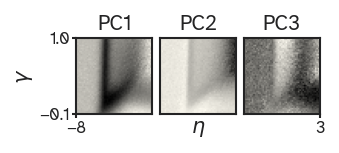

In [53]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Configuration
output_path = Path(base_path) / "method_evaluation"
output_path.mkdir(exist_ok=True)

# ============================================================================
# LOAD AND PREPARE DATA
# ============================================================================

def load_all_methods():
    """Load and combine all method data."""
    all_data_list = []
    loaded_methods = []
    
    for method in all_dist_measures:
        path = f"{base_path}/summary_indiv_{method}_for_exp_{experiment_name}.csv"
        try:
            df = pd.read_csv(path)
            metric_cols = [col for col in df.columns 
                          if col not in ["eta", "gamma", "network_index", "filename", "id"]]
            if metric_cols:
                df['metric_value'] = df[metric_cols[0]]
                df['method'] = method
                
                # Normalize metric_value to [0, 1]
                df["metric_value"] = (df["metric_value"] - df["metric_value"].min()) / \
                                      (df["metric_value"].max() - df["metric_value"].min())
                
                # Turn similarities into distances for specific metrics
                if metric_cols[0] in ['Resistance_subject_0', 'Communicability_subject_0']: 
                    df["metric_value"] = 1 - df["metric_value"]
                
                all_data_list.append(df[['eta', 'gamma', 'id', 'metric_value', 'method']])
                loaded_methods.append(method)
                print(f"  ✓ Loaded {method}")
        except FileNotFoundError:
            print(f"  ✗ File not found for {method}")
    
    all_data = pd.concat(all_data_list, ignore_index=True)
    
    # Create wide format
    wide_data = all_data.pivot_table(
        index=['eta', 'gamma', 'id'],
        columns='method',
        values='metric_value'
    ).reset_index()
    
    return wide_data, loaded_methods

def normalize_methods(data, methods):
    """Normalize each method to [0, 1] range."""
    normalized = data.copy()
    for method in methods:
        min_val = data[method].min()
        max_val = data[method].max()
        if max_val > min_val:
            normalized[method] = (data[method] - min_val) / (max_val - min_val)
    return normalized

# ============================================================================
# COMPUTE PCA AND CREATE PC LANDSCAPES
# ============================================================================

print("Loading data...")
data, methods = load_all_methods()
norm_data = normalize_methods(data, methods)

# Prepare data (remove NaNs)
X = norm_data[methods].dropna()
eta_gamma_coords = norm_data.loc[X.index, ['eta', 'gamma']].copy()

# Standardize
print("Running PCA...")
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# PCA
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

# Add PC scores back to dataframe with coordinates
eta_gamma_coords['PC1'] = X_pca[:, 0]
eta_gamma_coords['PC2'] = X_pca[:, 1]
eta_gamma_coords['PC3'] = X_pca[:, 2]

print(f"\nExplained variance:")
print(f"  PC1: {pca.explained_variance_ratio_[0]*100:.1f}%")
print(f"  PC2: {pca.explained_variance_ratio_[1]*100:.1f}%")
print(f"  PC3: {pca.explained_variance_ratio_[2]*100:.1f}%")

# ============================================================================
# CREATE PC MATRICES (similar to distance measure matrices)
# ============================================================================

def create_pc_matrix(df, pc_column):
    """Create a pivot matrix for a given PC column."""
    # Round eta and gamma
    df = df.copy()
    df['eta'] = df['eta'].round(2)
    df['gamma'] = df['gamma'].round(2)
    
    # Create pivot table
    df_pivot = df.pivot_table(index='gamma', columns='eta', values=pc_column, aggfunc='mean')
    
    # Min-max normalize to [0, 1] for visualization
    df_pivot_norm = (df_pivot - df_pivot.min().min()) / \
                     (df_pivot.max().max() - df_pivot.min().min())
    
    # Return reversed matrix (to match your visualization orientation)
    return df_pivot_norm.values[::-1]

pc_matrices = {
    'PC1': create_pc_matrix(eta_gamma_coords, 'PC1'),
    'PC2': create_pc_matrix(eta_gamma_coords, 'PC2'),
    'PC3': create_pc_matrix(eta_gamma_coords, 'PC3')
}

# ============================================================================
# PLOT PC LANDSCAPES
# ============================================================================


fig, axes = plt.subplots(1, 3, 
                         figsize=viz.cm_to_inch((6, 3)),
                         dpi=150)

pc_names = ['PC1', 'PC2', 'PC3']

for idx, (pc_name) in enumerate(pc_names):
    ax = axes[idx]
    
    # Create colormap
    # cmap = plt.cm.colors.LinearSegmentedColormap.from_list(
    #     f'custom_cmap_{pc_name}', 
    #     ["black", "white"]
    # )
    cmap = plt.cm.colors.LinearSegmentedColormap.from_list(
        f'custom_cmap_{mode}', 
        [
            "black",
            bone_white
        ])
    
    # Plot
    scatter = ax.imshow(pc_matrices[pc_name], 
                        cmap=cmap, 
                        aspect=np.round((8+3)/(1.1), 4), # 'equal', # auto',
                        extent=[
                            eta_gamma_coords["eta"].min(), 
                            eta_gamma_coords["eta"].max(),
                            eta_gamma_coords["gamma"].min(), 
                            eta_gamma_coords["gamma"].max()
                        ])
    
    # Set ticks
    if idx == 0:
        ax.set_yticks([np.ceil(eta_gamma_coords["gamma"].min()*10)/10, 
                       np.floor(eta_gamma_coords["gamma"].max()*10)/10])
        # ax.set_ylabel(None) # , fontsize=fontsize)
        ax.set_ylabel(r"$\gamma$")
        ax.set_xticks([-8])
    if idx == 1: 
        ax.set_yticks([])
        ax.set_xticks([])
        ax.set_xlabel(r"$\eta$")
    if idx == 2: 
        ax.set_yticks([])
        ax.set_xticks([3])
    
    
    # Add title showing explained variance
    variance_pct = pca.explained_variance_ratio_[idx] * 100
    # ax.set_title(f"{pc_name} ({variance_pct:.1f}%)") # , fontsize=fontsize+1)
    ax.set_title(f"{pc_name}") # , fontsize=fontsize+1)
    print(f"{pc_name} ({variance_pct:.1f}%)")

plt.tight_layout()
plt.subplots_adjust(wspace=0.1)

# Save
plt.savefig(output_path / "pc_landscapes_pc1_pc2_pc3.pdf", bbox_inches='tight')
print(f"Saved: {output_path / 'pc_landscapes_pc1_pc2_pc3.pdf'}")
plt.show()

# SAVE PC MATRICES FOR FURTHER ANALYSIS
# Save the actual PC score values (not normalized) for each eta-gamma pair
eta_gamma_coords_rounded = eta_gamma_coords.copy()
eta_gamma_coords_rounded['eta'] = eta_gamma_coords_rounded['eta'].round(2)
eta_gamma_coords_rounded['gamma'] = eta_gamma_coords_rounded['gamma'].round(2)
# eta_gamma_coords_rounded.to_csv(output_path / 'pc_scores_by_eta_gamma.csv', index=False)
# print(f"Saved: {output_path / 'pc_scores_by_eta_gamma.csv'}")

Loading data...
  ✓ Loaded frobenius
  ✓ Loaded net_simile
  ✓ Loaded spectral_distance_adjacency
  ✓ Loaded energy
  ✓ Loaded portrait
  ✓ Loaded communicability_corr
  ✓ Loaded delta_con
  ✓ Loaded netrd_non_backtracking_spectral
  ✓ Loaded resistance
Running PCA...

Explained variance:
  PC1: 51.4%
  PC2: 22.9%
  PC3: 10.3%

PC2 Loadings:
  resistance                    :  0.5959, PC2/PC1: -4.3714
  energy                        :  0.4519, PC2/PC1: 1.3377
  netrd_non_backtracking_spectral: -0.4274, PC2/PC1: -1.3533
  portrait                      :  0.2980, PC2/PC1: 0.7613
  communicability_corr          :  0.2915, PC2/PC1: -1.5235
  delta_con                     : -0.2384, PC2/PC1: -0.6981
  net_simile                    :  0.1183, PC2/PC1: 0.2985
  spectral_distance_adjacency   :  0.1118, PC2/PC1: 0.2632
  frobenius                     : -0.0290, PC2/PC1: -0.0826
PC1 (51.4%)
min val -5.050744944137361
max val 4.301871210605536


/opt/miniconda3/envs/ma_thesis/lib/python3.13/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: divide by zero encountered in matmul
  X_transformed = X @ self.components_.T
/opt/miniconda3/envs/ma_thesis/lib/python3.13/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: overflow encountered in matmul
  X_transformed = X @ self.components_.T
/opt/miniconda3/envs/ma_thesis/lib/python3.13/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: invalid value encountered in matmul
  X_transformed = X @ self.components_.T


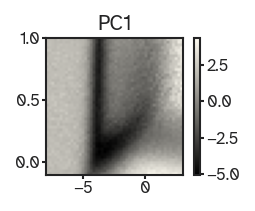

In [54]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Configuration
output_path = Path(base_path) / "method_evaluation"
output_path.mkdir(exist_ok=True)

# ============================================================================
# LOAD AND PREPARE DATA
# ============================================================================

def load_all_methods():
    """Load and combine all method data."""
    all_data_list = []
    loaded_methods = []
    
    for method in all_dist_measures:
        path = f"{base_path}/summary_indiv_{method}_for_exp_{experiment_name}.csv"
        try:
            df = pd.read_csv(path)
            metric_cols = [col for col in df.columns 
                          if col not in ["eta", "gamma", "network_index", "filename", "id"]]
            if metric_cols:
                df['metric_value'] = df[metric_cols[0]]
                df['method'] = method
                
                # Normalize metric_value to [0, 1]
                df["metric_value"] = (df["metric_value"] - df["metric_value"].min()) / \
                                      (df["metric_value"].max() - df["metric_value"].min())
                
                # Turn similarities into distances for specific metrics
                if metric_cols[0] in ['Resistance_subject_0', 'Communicability_subject_0']: 
                    df["metric_value"] = 1 - df["metric_value"]
                
                all_data_list.append(df[['eta', 'gamma', 'id', 'metric_value', 'method']])
                loaded_methods.append(method)
                print(f"  ✓ Loaded {method}")
        except FileNotFoundError:
            print(f"  ✗ File not found for {method}")
    
    all_data = pd.concat(all_data_list, ignore_index=True)
    
    # Create wide format
    wide_data = all_data.pivot_table(
        index=['eta', 'gamma', 'id'],
        columns='method',
        values='metric_value'
    ).reset_index()
    
    return wide_data, loaded_methods

def normalize_methods(data, methods):
    """Normalize each method to [0, 1] range."""
    normalized = data.copy()
    for method in methods:
        min_val = data[method].min()
        max_val = data[method].max()
        if max_val > min_val:
            normalized[method] = (data[method] - min_val) / (max_val - min_val)
    return normalized

# ============================================================================
# COMPUTE PCA AND CREATE PC LANDSCAPES
# ============================================================================

print("Loading data...")
data, methods = load_all_methods()
norm_data = normalize_methods(data, methods)

# Prepare data (remove NaNs)
X = norm_data[methods].dropna()
eta_gamma_coords = norm_data.loc[X.index, ['eta', 'gamma']].copy()

# Standardize
print("Running PCA...")
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# PCA
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

# Add PC scores back to dataframe with coordinates
eta_gamma_coords['PC1'] = X_pca[:, 0]
eta_gamma_coords['PC2'] = X_pca[:, 1]
eta_gamma_coords['PC3'] = X_pca[:, 2]

print(f"\nExplained variance:")
print(f"  PC1: {pca.explained_variance_ratio_[0]*100:.1f}%")
print(f"  PC2: {pca.explained_variance_ratio_[1]*100:.1f}%")
print(f"  PC3: {pca.explained_variance_ratio_[2]*100:.1f}%")

# Print loadings on PC2 
print(f"\nPC2 Loadings:")
for method, loading in loadings['PC2'].abs().sort_values(ascending=False).items():
    print(f"  {method:30s}: {loadings.loc[method, 'PC2']:7.4f}, PC2/PC1: {loadings.loc[method, 'PC2']/loadings.loc[method, 'PC1']:.4f}")
    

    
# ============================================================================
# CREATE PC MATRICES (similar to distance measure matrices)
# ============================================================================

def create_pc_matrix(df, pc_column):
    """Create a pivot matrix for a given PC column."""
    # Round eta and gamma
    df = df.copy()
    df['eta'] = df['eta'].round(2)
    df['gamma'] = df['gamma'].round(2)
    
    # Create pivot table
    df_pivot = df.pivot_table(index='gamma', columns='eta', values=pc_column, aggfunc='mean')
    
    # Min-max normalize to [0, 1] for visualization
    df_pivot_norm = df_pivot # (df_pivot - df_pivot.min().min()) / \
                    #  (df #_pivot.max().max() - df_pivot.min().min())
    
    # Return reversed matrix (to match your visualization orientation)
    return df_pivot_norm.values[::-1]

pc_matrices = {
    'PC1': create_pc_matrix(eta_gamma_coords, 'PC1'),
    'PC2': create_pc_matrix(eta_gamma_coords, 'PC2'),
    'PC3': create_pc_matrix(eta_gamma_coords, 'PC3')
}

# ============================================================================
# PLOT PC LANDSCAPES
# ============================================================================


fig, axes = plt.subplots(1, 1, 
                         figsize=viz.cm_to_inch((6, 3)),
                         dpi=150)

# pc_names = ['PC1', 'PC2', 'PC3']

for idx, pc_name in enumerate(["PC1"]):
    ax = axes

    # Create colormap
    # cmap = plt.cm.colors.LinearSegmentedColormap.from_list(
    #     f'custom_cmap_{pc_name}', 
    #     ["black", "white"]
    # )
    cmap = plt.cm.colors.LinearSegmentedColormap.from_list(
        f'custom_cmap_{mode}', 
        [
            "black",
            bone_white
        ])
    
    # Plot
    scatter = ax.imshow(pc_matrices[pc_name], 
                        cmap=cmap, 
                        aspect=np.round((8+3)/(1.1), 4), # 'equal', # auto',
                        extent=[
                            eta_gamma_coords["eta"].min(), 
                            eta_gamma_coords["eta"].max(),
                            eta_gamma_coords["gamma"].min(), 
                            eta_gamma_coords["gamma"].max()
                        ])

    # Set ticks
    # if idx == 0:
    #     ax.set_yticks([np.ceil(eta_gamma_coords["gamma"].min()*10)/10, 
    #                    np.floor(eta_gamma_coords["gamma"].max()*10)/10])
    #     # ax.set_ylabel(None) # , fontsize=fontsize)
    #     ax.set_ylabel(r"$\gamma$")
    #     ax.set_xticks([-8])
    # if idx == 1: 
    #     ax.set_yticks([])
    #     ax.set_xticks([])
    #     ax.set_xlabel(r"$\eta$")
    # if idx == 2: 
    #     ax.set_yticks([])
    #     ax.set_xticks([3])
    
    plt.colorbar(scatter, ax=ax, fraction=0.046, pad=0.04)
    
    # Add title showing explained variance
    variance_pct = pca.explained_variance_ratio_[idx] * 100
    # ax.set_title(f"{pc_name} ({variance_pct:.1f}%)") # , fontsize=fontsize+1)
    ax.set_title(f"{pc_name}") # , fontsize=fontsize+1)
    print(f"{pc_name} ({variance_pct:.1f}%)")
    print("min val", np.min(pc_matrices[pc_name]))
    print("max val", np.max(pc_matrices[pc_name]))

# plt.tight_layout()
# plt.subplots_adjust(wspace=0.1)

# # Save
# plt.savefig(output_path / "pc_landscapes_pc1_pc2_pc3.pdf", bbox_inches='tight')
# print(f"Saved: {output_path / 'pc_landscapes_pc1_pc2_pc3.pdf'}")
# plt.show()

# # SAVE PC MATRICES FOR FURTHER ANALYSIS
# # Save the actual PC score values (not normalized) for each eta-gamma pair
# eta_gamma_coords_rounded = eta_gamma_coords.copy()
# eta_gamma_coords_rounded['eta'] = eta_gamma_coords_rounded['eta'].round(2)
# eta_gamma_coords_rounded['gamma'] = eta_gamma_coords_rounded['gamma'].round(2)
# # eta_gamma_coords_rounded.to_csv(output_path / 'pc_scores_by_eta_gamma.csv', index=False)
# print(f"Saved: {output_path / 'pc_scores_by_eta_gamma.csv'}")

In [ ]:
# from sklearn.manifold import TSNE
# import umap

# # Run t-SNE and UMAP on the same X_scaled data used for PCA
# tsne = TSNE(n_components=2, random_state=42, perplexity=30)
# X_tsne = tsne.fit_transform(X_scaled)

# reducer = umap.UMAP(n_components=2, random_state=42)
# X_umap = reducer.fit_transform(X_scaled)

# # Color by PC1 score
# color_values = X_pca[:, 0]

# fig, axes = plt.subplots(1, 2, figsize=viz.cm_to_inch((12, 6)), dpi=150)

# cmap = plt.cm.colors.LinearSegmentedColormap.from_list(
#     'custom_bw', ["black", bone_white])

# # t-SNE
# sc0 = axes[0].scatter(X_tsne[:, 0], X_tsne[:, 1], c=color_values, cmap=cmap,
#                        s=1, alpha=0.5, rasterized=True)
# axes[0].set_xticks([])
# axes[0].set_yticks([])
# axes[0].text(0.05, 0.95, 't-SNE', transform=axes[0].transAxes,
#              verticalalignment='top',
#              bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor=halfblack, alpha=0.8))

# # UMAP
# sc1 = axes[1].scatter(X_umap[:, 0], X_umap[:, 1], c=color_values, cmap=cmap,
#                        s=1, alpha=0.5, rasterized=True)
# axes[1].set_xticks([])
# axes[1].set_yticks([])
# axes[1].text(0.05, 0.95, 'UMAP', transform=axes[1].transAxes,
#              verticalalignment='top',
#              bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor=halfblack, alpha=0.8))

# plt.tight_layout()
# plt.savefig(output_path / 'tsne_umap_colored_by_pc1.pdf', bbox_inches='tight')
# plt.show()